In [1]:
# Base imports
import os
import pickle
import re

# Compute imports
import numpy as np
import pandas as pd
import scipy
from tqdm.notebook import tqdm, trange
from collections import defaultdict

# Plotting imports
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px
import matplotlib.patches as mpatches
from pyphylon.util import load_config

# ML import
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, median_absolute_error
from sklearn.metrics.pairwise import cosine_similarity

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_style('ticks')
matplotlib.rcParams['text.color'] = '#000000'
matplotlib.rcParams['axes.labelcolor'] = '#000000'
matplotlib.rcParams['xtick.color'] = '#000000'
matplotlib.rcParams['ytick.color'] = '#000000'

In [2]:
df_genes = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/panaroo_results/gene_presence_absence.Rtab', sep = '\t').set_index('Gene')

In [3]:
# Load in A_binarized matrix
A_binarized = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/A_binarized.csv", index_col=0)

In [4]:
# Load in L_binarized matrix
L_binarized = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/L_binarized.csv", index_col=0)

In [5]:
# Load in L_norm matrix
L_norm = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/L_norm.csv", index_col=0)

In [6]:
# Load in A_norm matrix
A_norm = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/A_norm.csv", index_col=0)

/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


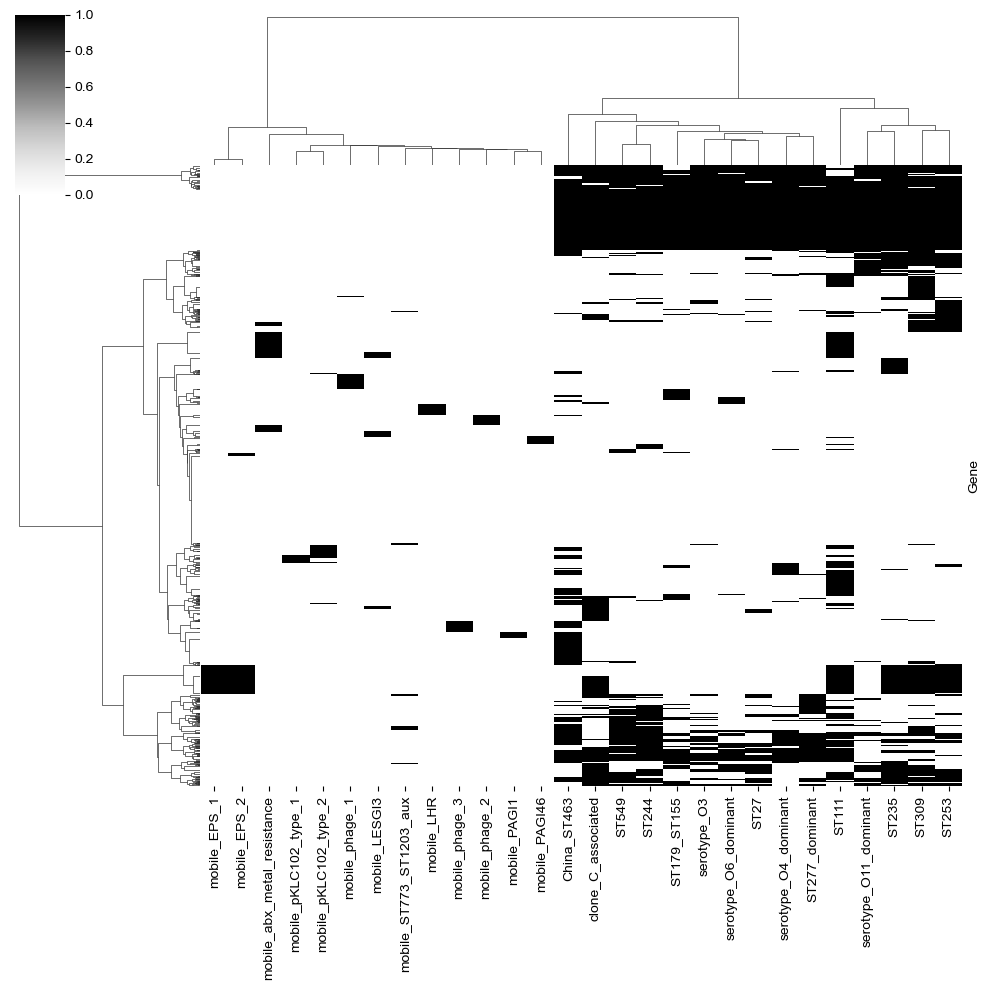

In [7]:
# Plot renamed L_binarized clustermap
g_bin = sns.clustermap(L_binarized,
                       method='ward',
                       metric='euclidean', # metric must be euclidean for ward (even if binarized)
                       cmap='Greys',
                       yticklabels=False,
                       robust=True
                      )

In [8]:
phylon_order = g_bin.data2d.columns.to_list()

  0%|          | 0/14 [00:00<?, ?it/s]

/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)


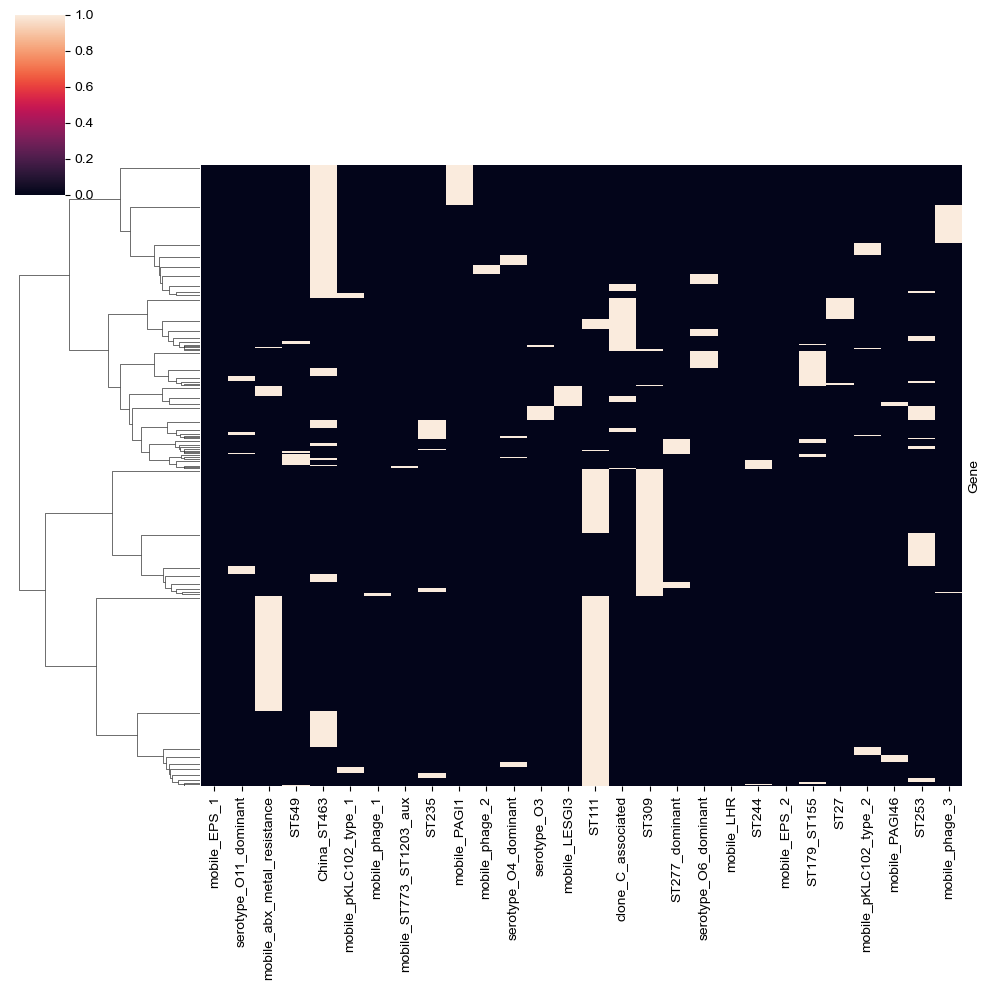

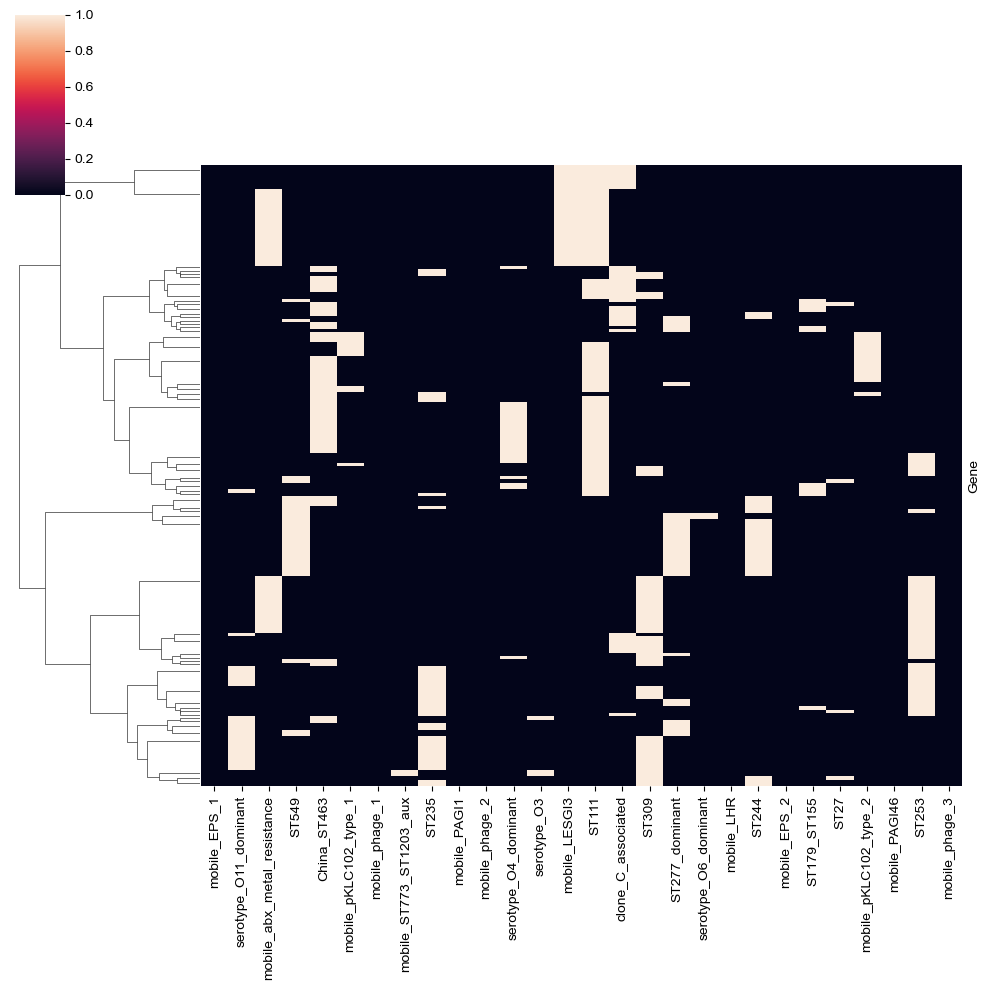

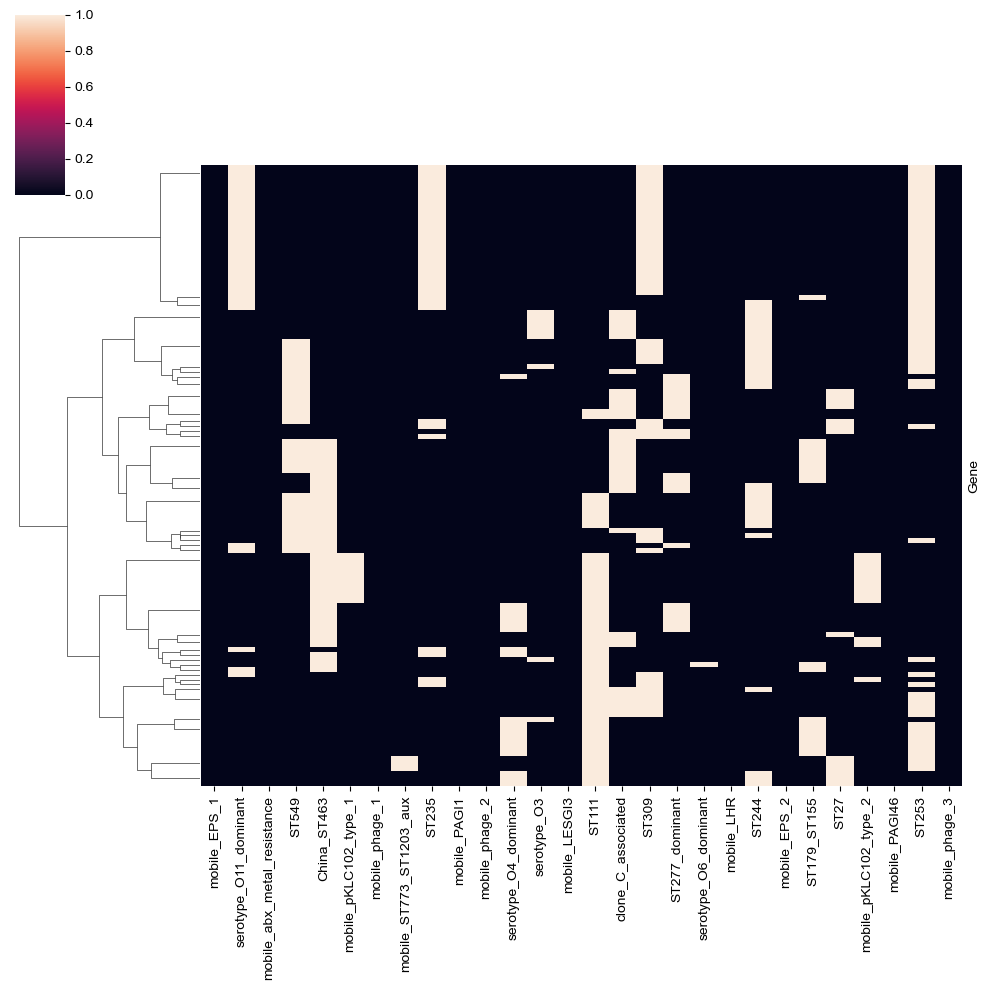

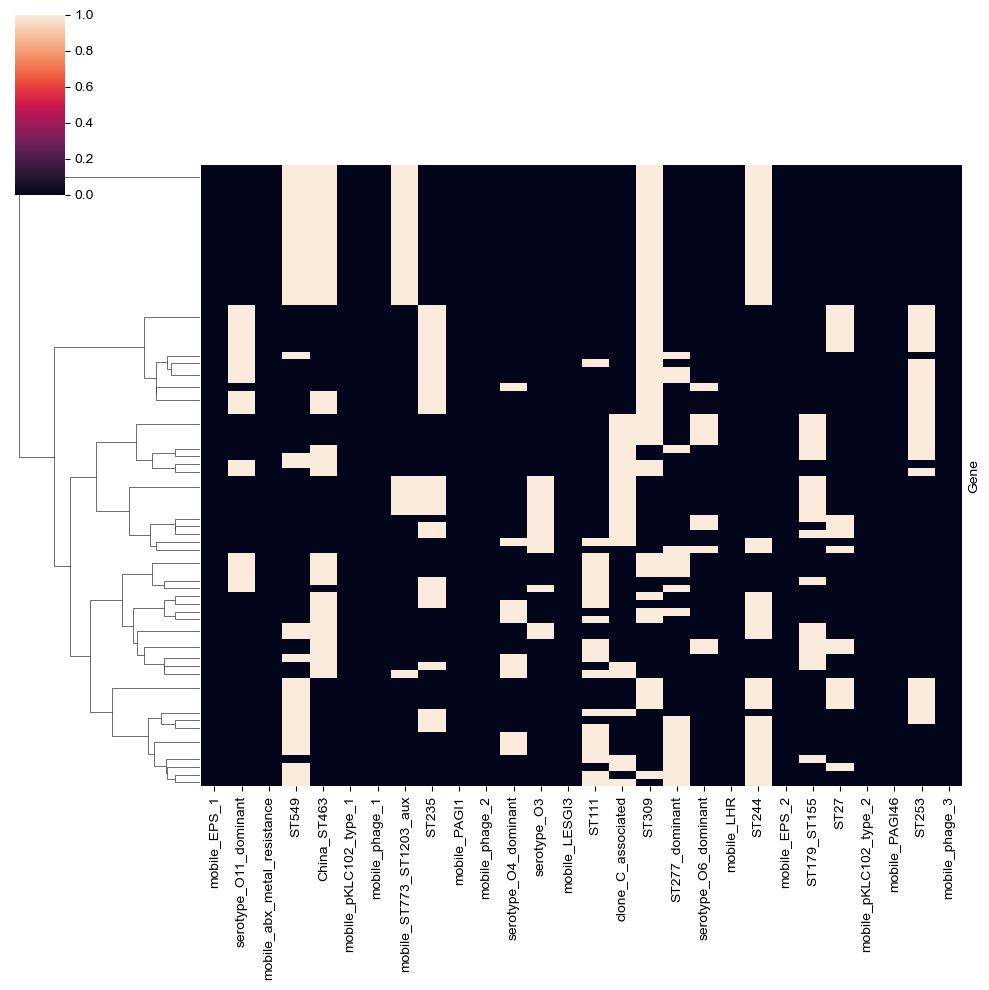

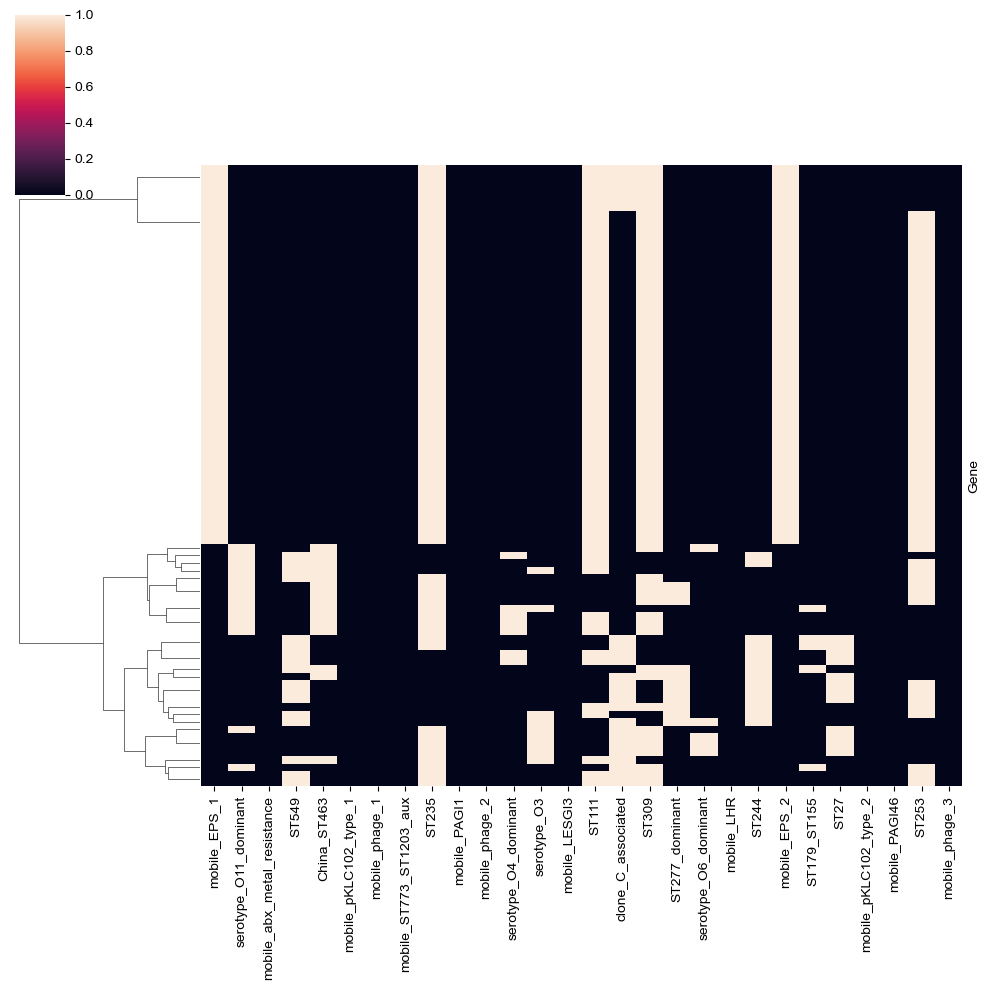

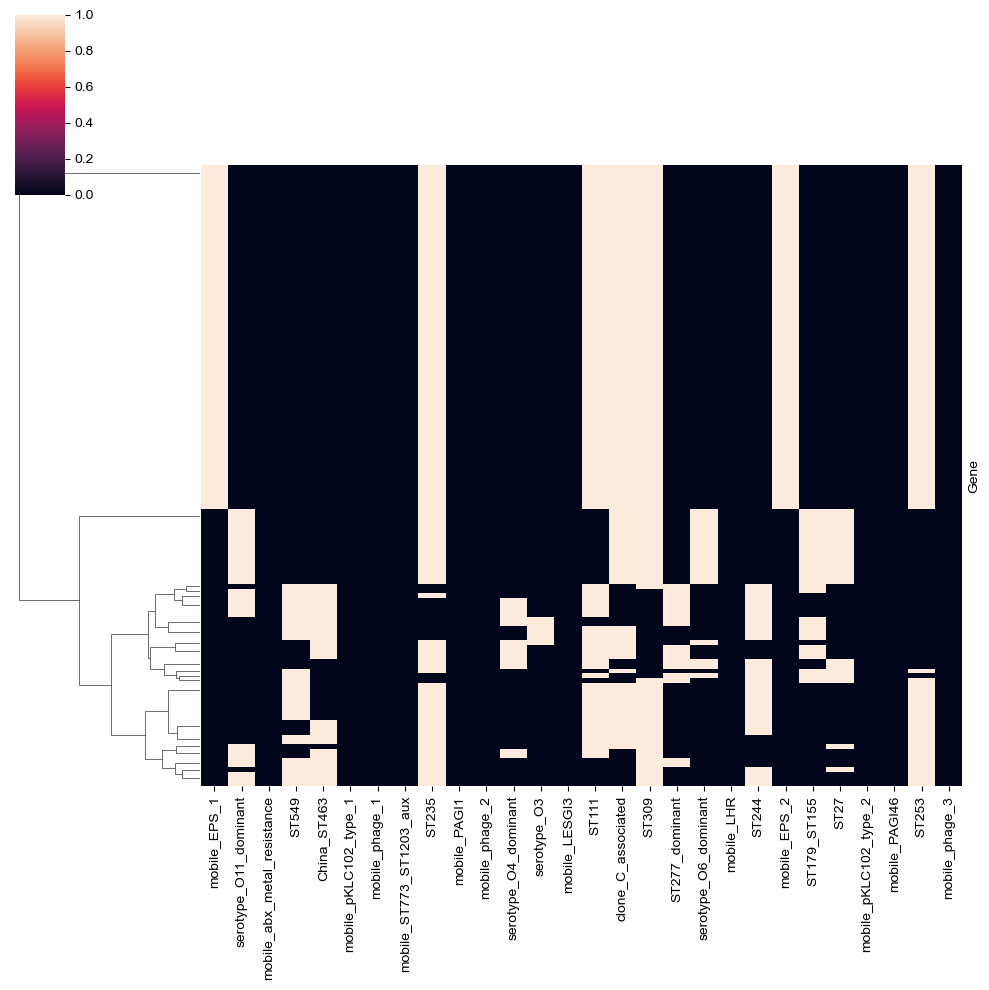

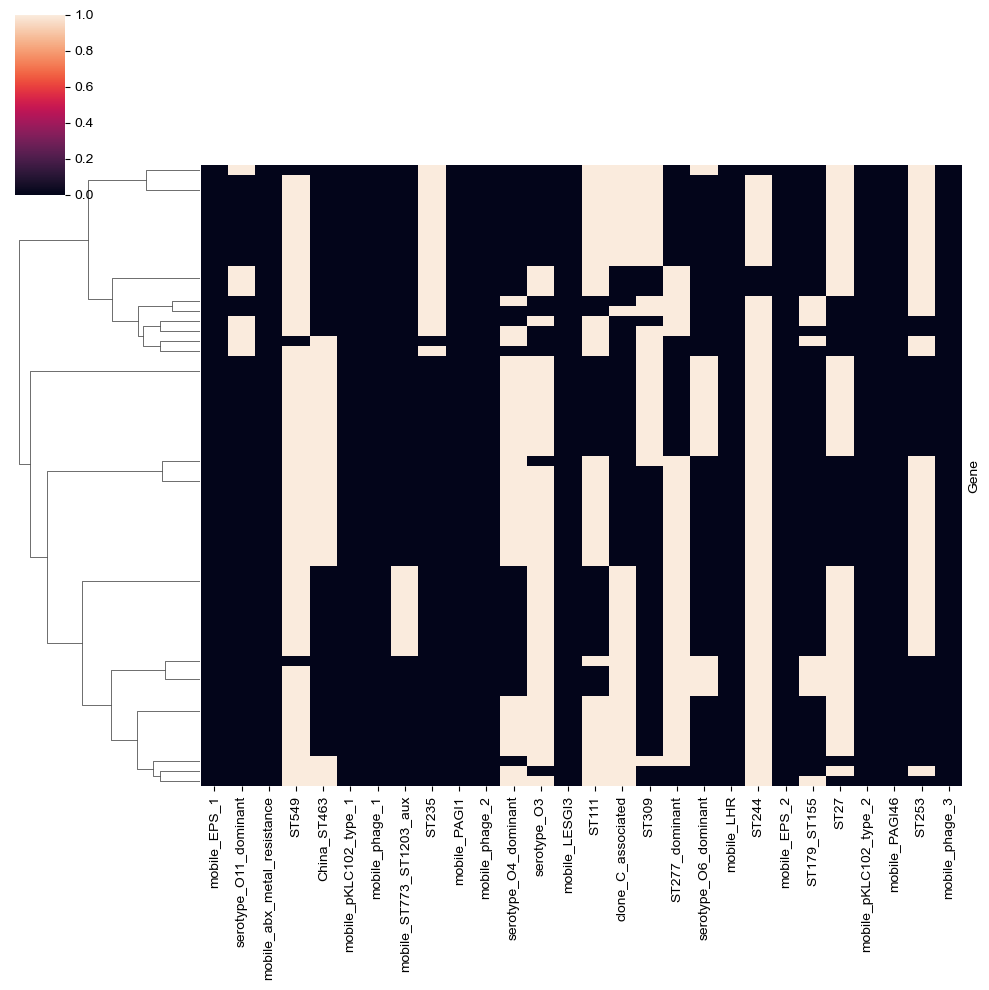

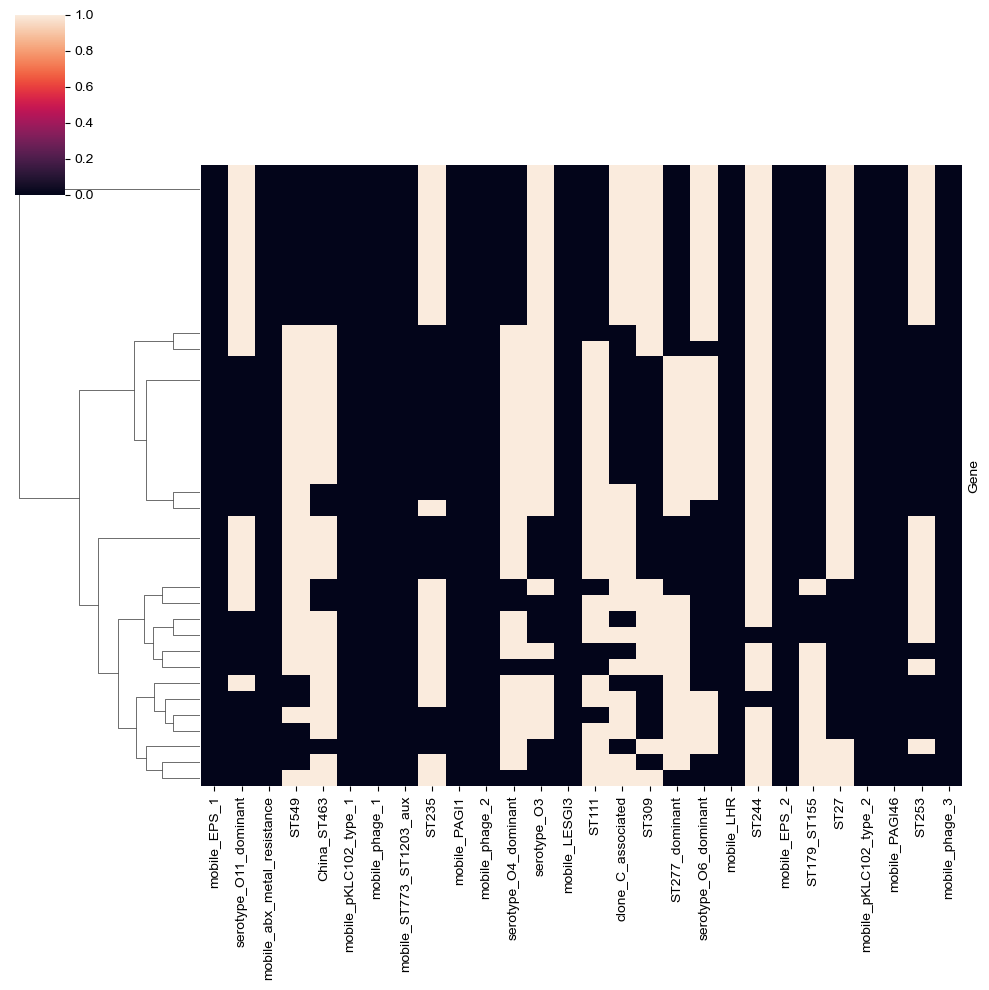

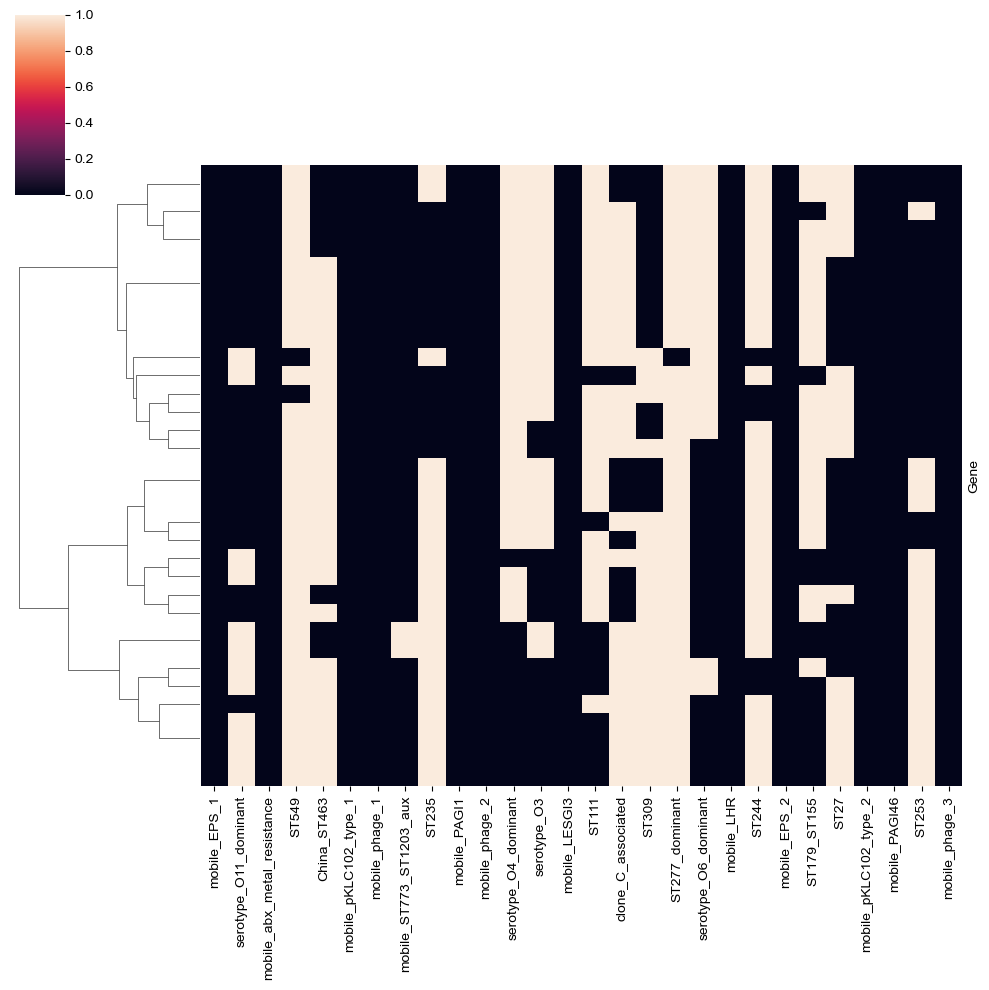

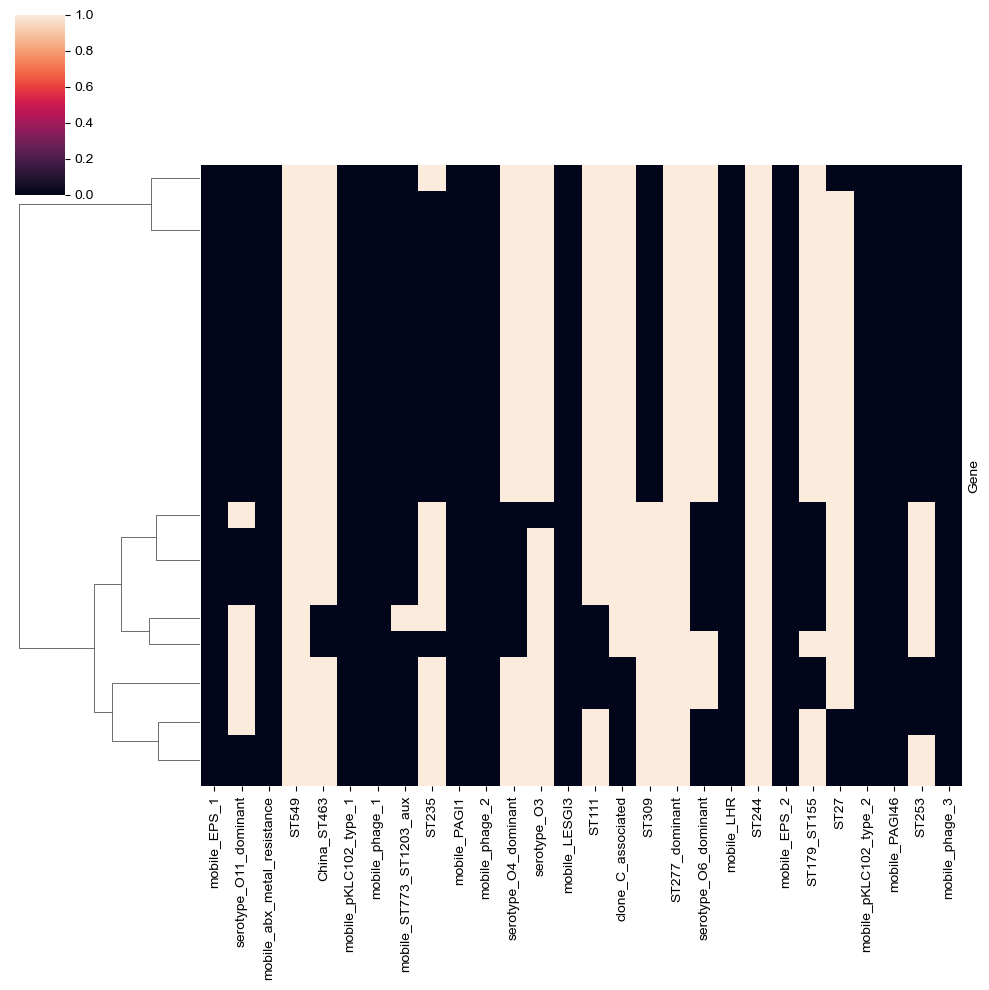

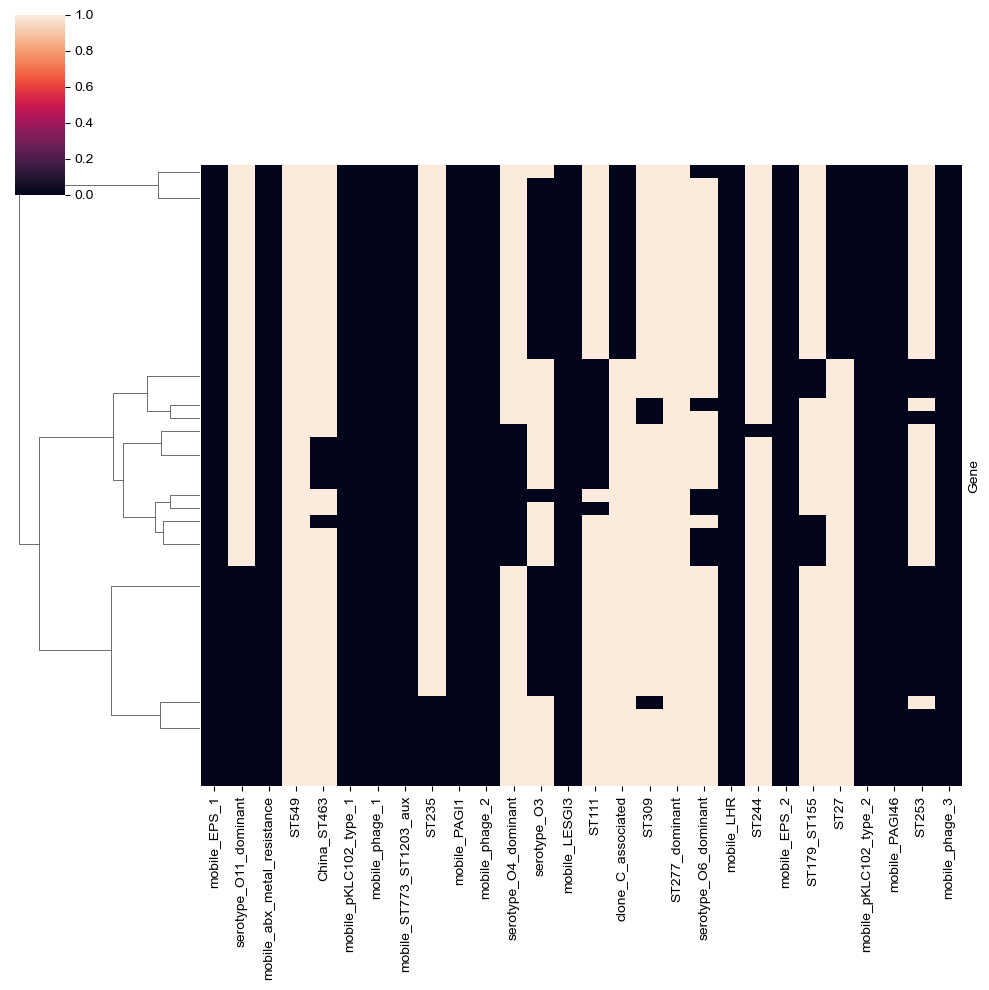

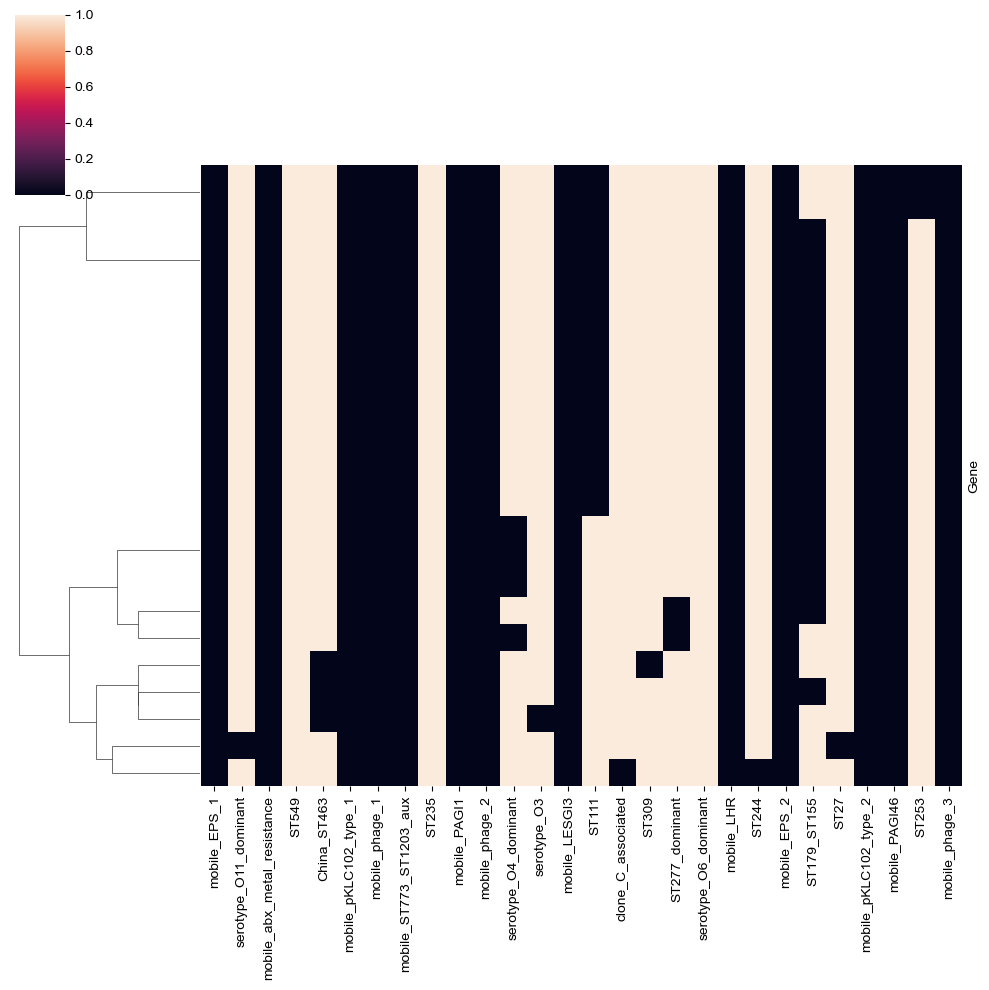

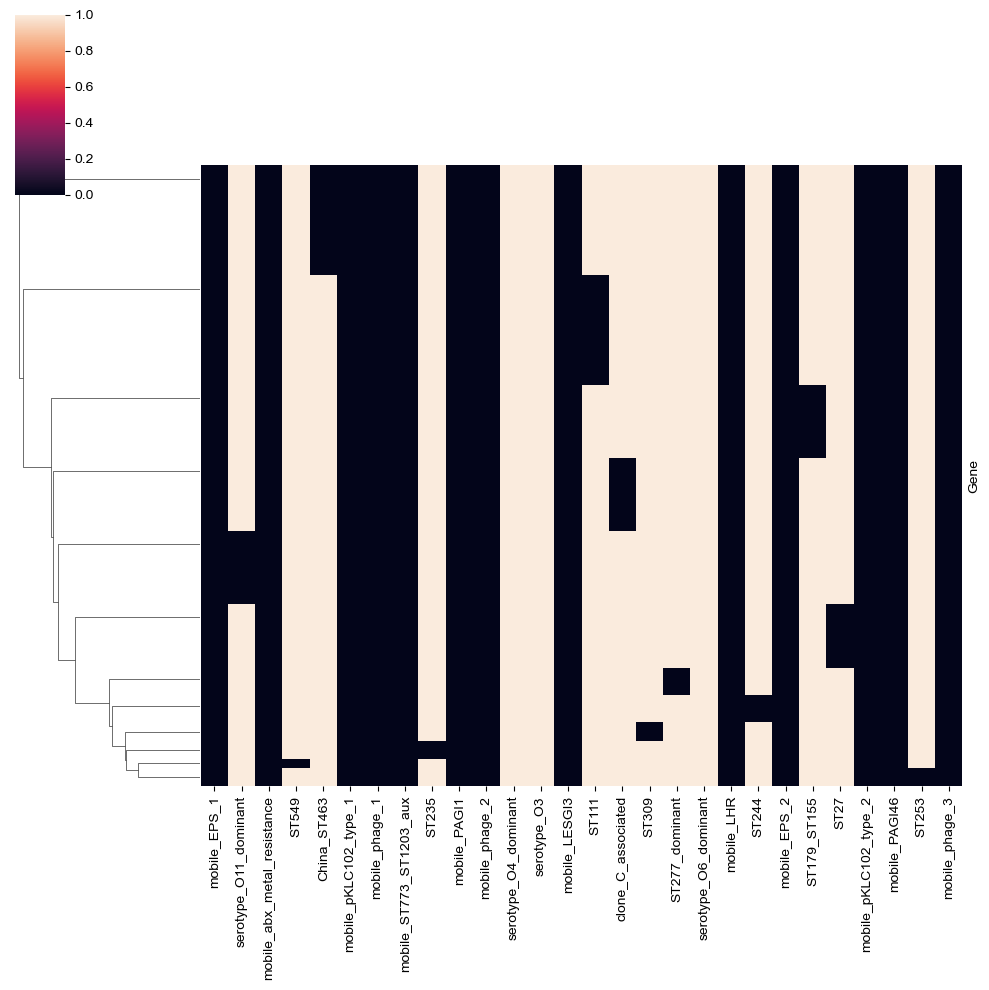

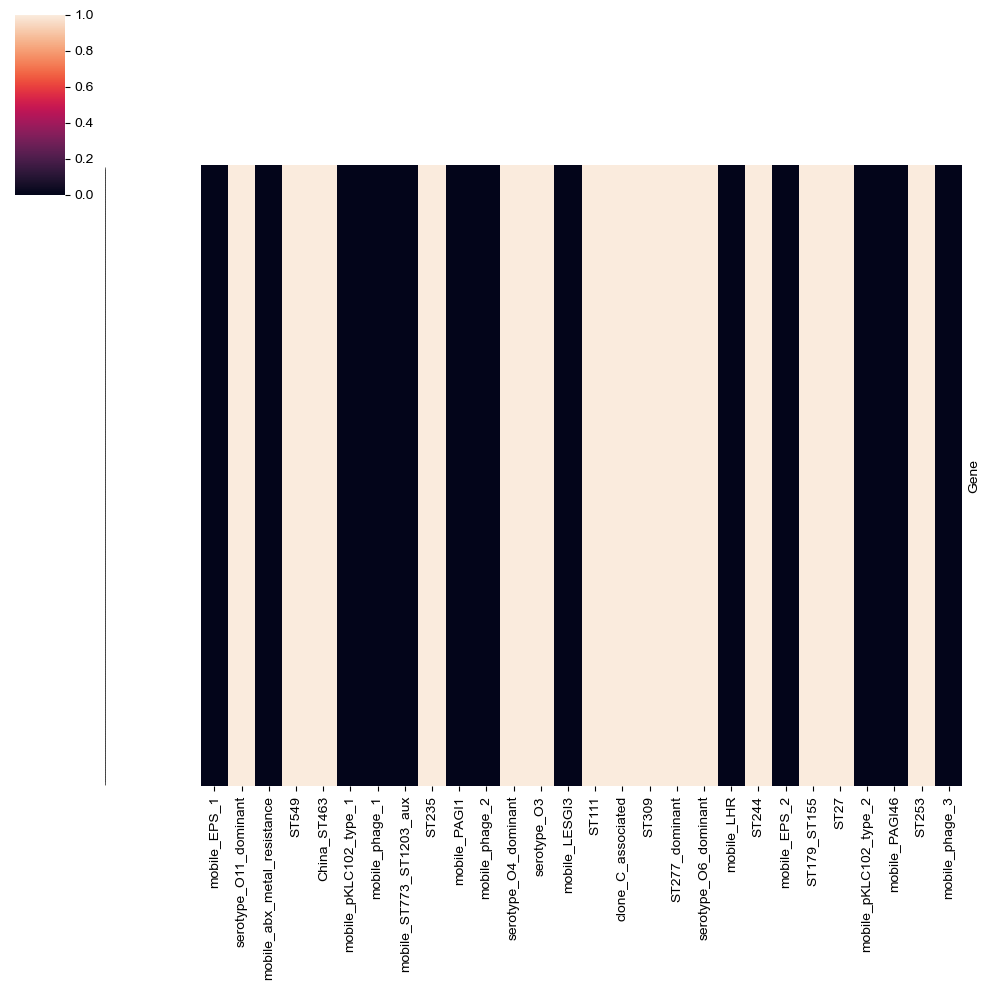

In [9]:
gene_order = []

# Add in zero-phylon genes
zero_cond = L_binarized.sum(axis=1) == 0
gene_order.extend(L_binarized[zero_cond].index)

# Add in single-phylon genes
for phylon in phylon_order:
    single_cond = L_binarized.sum(axis=1) == 1
    inPhylon = L_binarized[phylon] == 1
    gene_order.extend(L_binarized[inPhylon & single_cond].index)

# Add in poly-phylon genes
for num_active_phylons in trange(2, int(L_binarized.sum(axis=1).max())+1):
    num_cond = L_binarized.sum(axis=1) == num_active_phylons
    gg = sns.clustermap(L_binarized[num_cond], method='ward', metric='euclidean', col_cluster=False, yticklabels=False);
    gene_order.extend(gg.data2d.index)

/mnt/craig/pan_phylon/P_aeruginosa/heera-jupyterlab/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


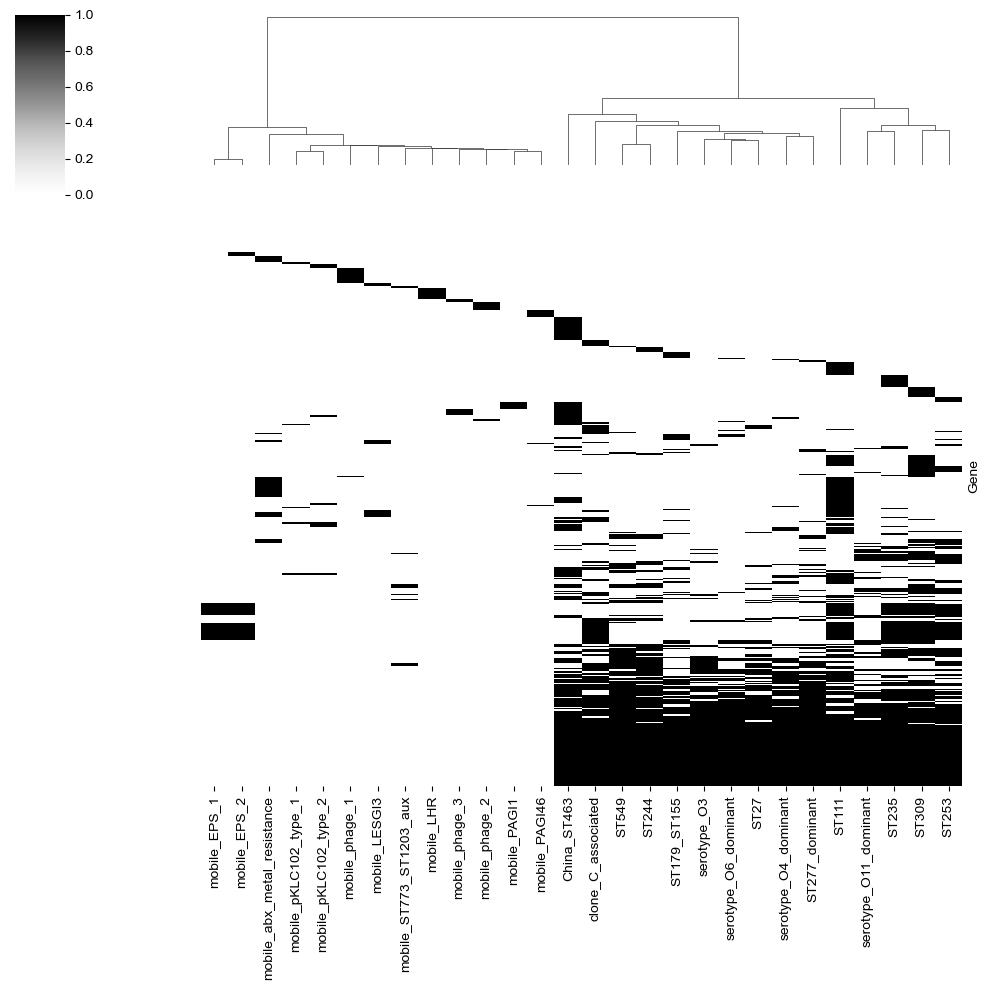

In [10]:
# Main sorted clustermap

g = sns.clustermap(
    L_binarized.loc[gene_order],
    method='ward',
    metric='euclidean',
    row_cluster=False,
    yticklabels=False,
    cmap='Greys'
)

In [11]:
cluster_functions = pd.read_csv('cluster_functions_annot.csv').drop('Unnamed: 0', axis = 1).set_index('cluster')

In [12]:
## virulence genes
vfdb_genes = pd.read_csv('panaroo_vfdb_hits.tsv', sep = '\t', header = None)
vfdb_genes.columns =  ["qseqid","sseqid", "pident", "length", "qcovhsp", "evalue", "bitscore", "stitle"]
vfdb_genes = vfdb_genes.set_index('qseqid')
vfdb_genes.head()

,sseqid,pident,length,qcovhsp,evalue,bitscore,stitle
qseqid,,,,,,,
group_3495,VFG002065(gb|NP_248769),100.0,444,100.0,0.000000e+00,874.0,VFG002065(gb|NP_248769) (hsiJ1) type VI secret...
group_19452,VFG002071(gb|NP_248775),100.0,162,100.0,2.390000e-101,285.0,VFG002071(gb|NP_248775) (hcp1) type VI secreti...
pilT,VFG001223(gb|NP_249086),100.0,344,100.0,1.680000e-246,667.0,VFG001223(gb|NP_249086) (pilT) twitching motil...
pilT,VFG050386(gb|WP_000355489.1),84.3,344,100.0,9.210000e-210,575.0,VFG050386(gb|WP_000355489.1) (pilT) type IV pi...
pilU,VFG001224(gb|NP_249087),100.0,382,100.0,2.150000e-275,744.0,VFG001224(gb|NP_249087) (pilU) twitching motil...


# Phylon split analysis

In [13]:
# number of genes in each phylon
L_binarized.sum()

mobile_EPS_1                    123.0
serotype_O11_dominant           554.0
mobile_abx_metal_resistance     159.0
ST549                           707.0
China_ST463                     900.0
mobile_pKLC102_type_1            38.0
mobile_phage_1                   64.0
mobile_ST773_ST1203_aux          47.0
ST235                           820.0
mobile_PAGI1                     29.0
mobile_phage_2                   42.0
serotype_O4_dominant            574.0
serotype_O3                     541.0
mobile_LESGI3                    61.0
ST111                          1046.0
clone_C_associated              779.0
ST309                           934.0
ST277_dominant                  636.0
serotype_O6_dominant            528.0
mobile_LHR                       46.0
ST244                           711.0
mobile_EPS_2                    136.0
ST179_ST155                     571.0
ST27                            571.0
mobile_pKLC102_type_2            61.0
mobile_PAGI46                    34.0
ST253       

In [14]:
phylon_order

['mobile_EPS_1',
 'mobile_EPS_2',
 'mobile_abx_metal_resistance',
 'mobile_pKLC102_type_1',
 'mobile_pKLC102_type_2',
 'mobile_phage_1',
 'mobile_LESGI3',
 'mobile_ST773_ST1203_aux',
 'mobile_LHR',
 'mobile_phage_3',
 'mobile_phage_2',
 'mobile_PAGI1',
 'mobile_PAGI46',
 'China_ST463',
 'clone_C_associated',
 'ST549',
 'ST244',
 'ST179_ST155',
 'serotype_O3',
 'serotype_O6_dominant',
 'ST27',
 'serotype_O4_dominant',
 'ST277_dominant',
 'ST111',
 'serotype_O11_dominant',
 'ST235',
 'ST309',
 'ST253']

# First split
genes in all non-mobile phylones

In [30]:
1535 + 280

1815

In [31]:
# Define the columns that should have 1s and the columns that should have 0s
## non-mobile
non_mobile_phylons = ['China_ST463',
                     'clone_C_associated',
                     'ST549',
                     'ST244',
                     'ST179_ST155',
                     'serotype_O3',
                     'serotype_O6_dominant',
                     'ST27',
                     'serotype_O4_dominant',
                     'ST277_dominant',
                     'ST111',
                     'serotype_O11_dominant',
                     'ST235',
                     'ST309',
                     'ST253']

# mobile
mobile_phylons = ['mobile_EPS_1',
                    'mobile_EPS_2',
                    'mobile_abx_metal_resistance',
                    'mobile_pKLC102_type_1',
                    'mobile_pKLC102_type_2',
                    'mobile_phage_1',
                    'mobile_LESGI3',
                    'mobile_ST773_ST1203_aux',
                    'mobile_LHR',
                    'mobile_phage_3',
                    'mobile_phage_2',
                    'mobile_PAGI1',
                    'mobile_PAGI46']

mobile_exclusive = L_binarized.loc[(L_binarized[non_mobile_phylons].sum(axis=1) == 0) & (L_binarized[mobile_phylons].sum(axis=1) > 0)]
non_mobile_exclusive = L_binarized.loc[(L_binarized[non_mobile_phylons].sum(axis=1) > 0) & (L_binarized[mobile_phylons].sum(axis=1) == 0)]

In [32]:
len(non_mobile_exclusive)
# L_binarized.loc[non_mobile_exclusive.index.values].sum()

1535

In [33]:
len(mobile_exclusive)
# L_binarized.loc[mobile_exclusive.index.values].sum()

280

In [34]:
# sanity check
## 366 genes not in phylons
## total should be 2612 -- size of acc genome
len(mobile_exclusive) + len(non_mobile_exclusive) + len(L_binarized.loc[(L_binarized[non_mobile_phylons].sum(axis=1) > 0) & (L_binarized[mobile_phylons].sum(axis=1) > 0)]) + 366

2612

In [35]:
# shared by all mobile phylons only

mask = (
    L_binarized.loc[mobile_exclusive.index, mobile_phylons].all(axis=1) &
    ~L_binarized.loc[mobile_exclusive.index, list(set(phylon_order).difference(set(mobile_phylons)))].any(axis=1)
)

L_binarized.loc[mobile_exclusive.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [36]:
# shared by all non-mobile phylons only

mask = (
    L_binarized.loc[non_mobile_exclusive.index, non_mobile_phylons].all(axis=1) &
    ~L_binarized.loc[non_mobile_exclusive.index, list(set(phylon_order).difference(set(non_mobile_phylons)))].any(axis=1)
)

shared_non_mobile = L_binarized.loc[non_mobile_exclusive.index][mask]
shared_non_mobile

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_14781,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
group_19708,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
ybdN,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
group_23154,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
group_25324,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_14913,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
group_24758,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
group_20164,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [37]:
# shared by all non-mobile phylons
cluster_functions.loc[shared_non_mobile.index.values].AMRFinder_cluster.value_counts()

AMRFinder_cluster
catB7~~~catB    1
Name: count, dtype: int64

In [38]:
cluster_functions.loc[list(set(L_binarized.loc[non_mobile_exclusive.index][mask].index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
eta~~~toxA,exotoxin A,"BlastRules:WP_023114091, EC:2.4.2.36, GO:00167...",eta~~~toxA,M,Exotoxin A catalytic,-,-,ko:K11020,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000774
tas1~~~pAAR~~~tse6,T6SS effector (p)ppApp synthetase Tas1,"BlastRules:WP_015502132, GO:0005576, RefSeq:WP...",tas1~~~pAAR~~~tse6,S,PAAR motif,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000773
phzE,phenazine biosynthesis protein PhzE,"BlastRules:WP_003118954, COG:COG0512, COG:EH, ...",phzE,EH,chorismate binding enzyme,-,2.6.1.86,ko:K13063,"ko00405,ko01130,ko02024,map00405,map01130,map0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000777
group_18737,phenazine biosynthesis protein PhzF,"BlastRules:WP_003093628, COG:COG0384, COG:R, E...",group_18737,S,Phenazine biosynthesis-like protein,-,5.3.3.17,ko:K06998,"ko00405,ko01130,ko02024,map00405,map01130,map0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000778
rhlI,acyl-homoserine-lactone synthase,"BlastRules:WP_003113896, EC:2.3.1.184, GO:0007...",rhlI,H,Acyl-homoserine-lactone synthase,-,2.3.1.184,"ko:K13061,ko:K20250","ko00270,ko01100,ko02020,ko02024,ko02025,map002...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
exsE,T3SS regulon translocated regulator ExsE,"BlastRules:WP_003100766, GO:0005576, GO:000573...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_18342,YscW family type III secretion system pilotin ...,"BlastRules:WP_003100765, GO:0009279, RefSeq:WP...",group_18342,S,Type III secretion system lipoprotein chaperon...,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
sctE~~~popB~~~sseC,Type III secretion system effector SseC (host ...,"COG:COG5613, COG:U, RefSeq:WP_031685928.1, SO:...",sctE~~~popB~~~sseC,S,Secretion system effector C (SseC) like family,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
asnB~~~phzH,phenazine-modifying enzyme,"COG:COG0367, COG:E, EC:6.3.5.4, GO:0004066, GO...",asnB~~~phzH,E,Asparagine synthase,-,6.3.5.4,ko:K01953,"ko00250,ko01100,ko01110,map00250,map01100,map0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000759


### Shared genes across shared_non_mobile

In [39]:
def clean_cog(entry):
    if pd.isna(entry):
        return "missing"
    
    entry_str = str(entry).strip()
    
    if entry_str == "" or entry_str == "-":
        return "missing"
    
    return entry_str

# apply to df
cluster_functions["eggnog_COG_category"] = (
    cluster_functions["eggnog_COG_category"].apply(clean_cog)
)

In [40]:
# for acc genome only
df_acc_complete = pd.read_csv("/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/panaroo_results/CAR_genomes/df_acc.csv", index_col=0)

acc_cog_dict = {}

for cog in cluster_functions.loc[df_acc_complete.index].eggnog_COG_category.values:
    if cog != 'missing':
        for c in cog:
            if c not in acc_cog_dict.keys():
                acc_cog_dict[c] = 0
                acc_cog_dict[c] += 1
            else:
                acc_cog_dict[c] += 1
    elif cog == 'missing':
        if cog not in acc_cog_dict.keys():
            acc_cog_dict[cog] = 0
            acc_cog_dict[cog] += 1
        else:
            acc_cog_dict[cog] += 1

In [41]:
# for shared non-mobile genes only
subset_cog_dict = {}

for cog in cluster_functions.loc[shared_non_mobile.index].eggnog_COG_category.values:
    if cog != 'missing':
        for c in cog:
            if c not in subset_cog_dict.keys():
                subset_cog_dict[c] = 0
                subset_cog_dict[c] += 1
            else:
                subset_cog_dict[c] += 1
    elif cog == 'missing':
        if cog not in subset_cog_dict.keys():
            subset_cog_dict[cog] = 0
            subset_cog_dict[cog] += 1
        else:
            subset_cog_dict[cog] += 1

In [42]:
from scipy.stats import fisher_exact

results = []

subset_total = sum(subset_cog_dict.values())
acc_total = sum(acc_cog_dict.values())

all_cogs = set(subset_cog_dict) | set(acc_cog_dict)

for cog in all_cogs:
    a = subset_cog_dict.get(cog, 0)
    b = acc_cog_dict.get(cog, 0)

    table = [
        [a, subset_total - a],
        [b, acc_total - b]
    ]

    oddsratio, pvalue = fisher_exact(table, alternative="greater")  # enrichment of subset in acc specifically

    results.append((cog, oddsratio, pvalue))

In [43]:
from statsmodels.stats.multitest import multipletests
import pandas as pd

cogs = [r[0] for r in results]
odds = [r[1] for r in results]
pvals = [r[2] for r in results]

_, qvals, _, _ = multipletests(pvals, method="fdr_bh")

In [44]:
df = pd.DataFrame({
    "COG": cogs,
    "odds_ratio": odds,
    "pvalue": pvals,
    "qvalue": qvals
}).sort_values("qvalue")

df

,COG,odds_ratio,pvalue,qvalue
3,E,2.326700,0.000817,0.008987
7,P,2.350502,0.000451,0.008987
13,G,2.554136,0.001535,0.011255
8,K,1.604870,0.018070,0.099383
15,I,1.948571,0.043092,0.163539
18,C,1.776173,0.044601,0.163539
17,H,2.232389,0.075666,0.208082
20,T,1.833076,0.069226,0.208082
12,A,9.593103,0.180396,0.440969
5,J,1.922222,0.239264,0.478528


# Non-mobile phylons: Upper and Lower phylon split
non-mobile phylons only
total of 1535 genes

In [45]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
upper_phylons = ['China_ST463',
                 'clone_C_associated',
                 'ST549',
                 'ST244',
                 'ST179_ST155',
                 'serotype_O3',
                 'serotype_O6_dominant',
                 'ST27',
                 'serotype_O4_dominant',
                 'ST277_dominant']

# lower
lower_phylons = ['ST111',
                 'serotype_O11_dominant',
                 'ST235',
                 'ST309',
                 'ST253']

upper_split = non_mobile_exclusive.loc[(non_mobile_exclusive[lower_phylons].sum(axis=1) == 0) & (non_mobile_exclusive[upper_phylons].sum(axis=1) > 0)]
lower_split = non_mobile_exclusive.loc[(non_mobile_exclusive[lower_phylons].sum(axis=1) > 0) & (non_mobile_exclusive[upper_phylons].sum(axis=1) == 0)]

In [46]:
upper_split

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
gatA,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
group_26515,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_33509,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_16128,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_5944,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_23186,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
rfaB~~~wbpH,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ydaT,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
lower_split

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_22295,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_25778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_21319,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_35221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_35087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_27293,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_20153,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
cluster_functions.loc[upper_split.index].eggnog_COG_category.value_counts()

eggnog_COG_category
missing    118
S           71
L           30
M           24
E           15
K           13
C           11
U           11
Q            5
P            4
J            3
I            3
V            3
KL           3
GM           3
O            2
D            2
H            2
MU           1
EGP          1
G            1
T            1
F            1
IQ           1
NU           1
OU           1
Name: count, dtype: int64

In [49]:
# print(*cluster_functions.loc[upper_split.index]['product'], sep = '; ')

In [50]:
lower_split
# L_binarized.loc[lower_split.index.values].sum()

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_22295,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_25778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_21319,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_35221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_35087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_27293,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_20153,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
cluster_functions.loc[lower_split.index].eggnog_COG_category.value_counts()

eggnog_COG_category
missing    84
S          50
L          44
K          25
U          19
M          15
P          10
C           9
E           8
O           6
T           5
NU          4
Q           3
H           3
GM          2
I           2
MU          2
OU          2
V           2
D           2
KT          2
J           2
CH          2
G           1
IQ          1
EM          1
EGP         1
MOU         1
ET          1
KL          1
Name: count, dtype: int64

In [52]:
# shared by all lower phylons only

mask = (
    L_binarized.loc[lower_split.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[lower_split.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[lower_split.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_28762,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [53]:
set(L_binarized.loc[lower_split.index][mask].index.values).intersection(set(vfdb_genes.index.values))

set()

In [57]:
for gene in cluster_functions.loc[upper_split.index]['product'].values:
    if gene.__contains__('efflux'):
        print(gene)

In [58]:
# shared by all upper phylons only

mask = (
    L_binarized.loc[upper_split.index, upper_phylons].all(axis=1) &
    ~L_binarized.loc[upper_split.index, list(set(phylon_order).difference(set(upper_phylons)))].any(axis=1)
)

L_binarized.loc[upper_split.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [59]:
# shared by all upper and all lower -- geen list in section above
len(non_mobile_exclusive.loc[(non_mobile_exclusive[upper_phylons].sum(axis=1) == len(upper_phylons)) & (non_mobile_exclusive[lower_phylons].sum(axis=1) == len(lower_phylons))])

259

In [60]:
# sanity check -- should be equal to 1535 (unique + shared )
len(lower_split) + len(upper_split) + len(non_mobile_exclusive.loc[(non_mobile_exclusive[upper_phylons].sum(axis=1)> 0) & (non_mobile_exclusive[lower_phylons].sum(axis=1) > 0)])

1535

# First split of upper phylons
 total of 331 genes

In [61]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
upper_phylons_1 = ['China_ST463']

# lower
upper_phylons_2 = ['clone_C_associated',
                 'ST549',
                 'ST244',
                 'ST179_ST155',
                 'serotype_O3',
                 'serotype_O6_dominant',
                 'ST27',
                 'serotype_O4_dominant',
                 'ST277_dominant']

China_ST463_unique = upper_split.loc[(upper_split[upper_phylons_1].sum(axis=1) > 0) & (upper_split[upper_phylons_2].sum(axis=1) == 0)]
all_other_upper = upper_split.loc[(upper_split[upper_phylons_1].sum(axis=1) == 0) & (upper_split[upper_phylons_2].sum(axis=1) > 0)]

In [62]:
China_ST463_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_26515,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_33509,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_26048,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_24603,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_9376,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_22570,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8802,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34604,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
# unique vfs
cluster_functions.loc[list(set(China_ST463_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_22674,IS3-like element ISPa32 family transposase,"SO:0001217, UniRef:UniRef50_A0A6M3V4H4, UniRef...",group_22674,L,Integrase core domain,-,-,ko:K07497,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [64]:
# plasmid genes
cluster_functions.loc[China_ST463_unique.index][
        cluster_functions.loc[China_ST463_unique.index]['plasmid_fraction'] > 0.5
    ]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
Gene,,,,,,,,,,,,,,,,,,


In [65]:
#sanity check
# L_binarized.loc[China_ST463_unique.index.values].sum(axis = 1).sort_values()
# L_binarized.loc[China_ST463_unique.index.values].sum(axis = 0).sort_values()

In [66]:
# unique to all other upper
upper_split.loc[(upper_split[upper_phylons_1].sum(axis=1) == 0) & (upper_split[upper_phylons_2].sum(axis=1) > 0)]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_16128,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27788,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
group_2977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
fhaB~~~tpsA1~~~ibpA~~~cdiA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_32046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
group_23185,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_23186,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
# upper_split.loc[(upper_split[upper_phylons_1].sum(axis=1) == 0) & (upper_split[upper_phylons_2].sum(axis=1) > 0)].index.values

In [68]:
# shared by all other upper
mask = (
    L_binarized.loc[all_other_upper.index, upper_phylons_2].all(axis=1) &
    ~L_binarized.loc[all_other_upper.index, list(set(phylon_order).difference(set(upper_phylons_2)))].any(axis=1)
)

L_binarized.loc[all_other_upper.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [69]:
#sanity check
len(upper_split.loc[(upper_split[upper_phylons_1].sum(axis=1) == 0) & (upper_split[upper_phylons_2].sum(axis=1) > 0)]) + len(China_ST463_unique) + len(upper_split.loc[(upper_split[upper_phylons_1].sum(axis=1)> 0) & (upper_split[upper_phylons_2].sum(axis=1) > 0)])

331

# Second split of uppers
 total of 179 genes

In [70]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
upper_phylons_1 = ['clone_C_associated']

## lower
upper_phylons_2 = ['ST549',
                 'ST244',
                 'ST179_ST155',
                 'serotype_O3',
                 'serotype_O6_dominant',
                 'ST27',
                 'serotype_O4_dominant',
                 'ST277_dominant']

clone_C_associated_unique = all_other_upper.loc[(all_other_upper[upper_phylons_1].sum(axis=1) > 0) & (all_other_upper[upper_phylons_2].sum(axis=1) == 0)]
all_other_upper_2 = all_other_upper.loc[(all_other_upper[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper[upper_phylons_2].sum(axis=1) > 0)]

In [71]:
len(clone_C_associated_unique)

25

In [72]:
# unique vfs
cluster_functions.loc[list(set(clone_C_associated_unique.index).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [73]:
cluster_functions.loc[clone_C_associated_unique.index.values].eggnog_COG_category.value_counts()

eggnog_COG_category
S          7
missing    6
L          5
M          2
U          1
K          1
C          1
NU         1
OU         1
Name: count, dtype: int64

In [74]:
# plasmid genes
cluster_functions.loc[clone_C_associated_unique.index.values][
        cluster_functions.loc[clone_C_associated_unique.index.values]['plasmid_fraction'] > 0.5
    ]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [75]:
# shared by all other upper
mask = (
    L_binarized.loc[all_other_upper_2.index, upper_phylons_2].all(axis=1) &
    ~L_binarized.loc[all_other_upper_2.index, list(set(phylon_order).difference(set(upper_phylons_2)))].any(axis=1)
)

L_binarized.loc[all_other_upper_2.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [76]:
# unique to all other upper
all_other_upper.loc[(all_other_upper[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper[upper_phylons_2].sum(axis=1) > 0)]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_16128,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_2977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
fhaB~~~tpsA1~~~ibpA~~~cdiA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_19698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
group_23185,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_23186,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
# sanity check -- should be 179
len(clone_C_associated_unique) +  len(all_other_upper.loc[(all_other_upper[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper[upper_phylons_2].sum(axis=1) > 0)]) + len(all_other_upper.loc[(all_other_upper[upper_phylons_1].sum(axis=1)> 0) & (all_other_upper[upper_phylons_2].sum(axis=1) > 0)])

179

# Third split of uppers
114 genes

In [78]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
upper_phylons_1 = ['ST549',
                 'ST244']

## lower
upper_phylons_2 = ['ST179_ST155',
                 'serotype_O3',
                 'serotype_O6_dominant',
                 'ST27',
                 'serotype_O4_dominant',
                 'ST277_dominant']

ST549_244_unique = all_other_upper_2.loc[(all_other_upper_2[upper_phylons_1].sum(axis=1) > 0) & (all_other_upper_2[upper_phylons_2].sum(axis=1) == 0)]
all_other_upper_3 = all_other_upper_2.loc[(all_other_upper_2[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper_2[upper_phylons_2].sum(axis=1) > 0)]

In [79]:
ST549_244_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_27536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
opdE,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34325,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_28330,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_18371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_13371,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_13253,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_25270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_25981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [80]:
# unique vfs
cluster_functions.loc[list(set(ST549_244_unique.index.values).intersection(set(vfdb_genes.index)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [81]:
# shared by ST549 and 244
mask = (
    L_binarized.loc[ST549_244_unique.index, upper_phylons_1].all(axis=1) &
    ~L_binarized.loc[ST549_244_unique.index, list(set(phylon_order).difference(set(upper_phylons_1)))].any(axis=1)
)

L_binarized.loc[ST549_244_unique.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_13371,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_13253,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17552,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17694,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [82]:
cluster_functions.loc[L_binarized.loc[ST549_244_unique.index][mask].index]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
Gene,,,,,,,,,,,,,,,,,,
group_13371,hypothetical protein,"RefSeq:WP_003112391.1, SO:0001217, UniParc:UPI...",NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_13253,DUF2290 domain-containing protein,"COG:COG5619, COG:S, RefSeq:WP_003112393.1, SO:...",group_13253,S,Uncharacterized conserved protein (DUF2290),-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_17552,DUF4209 domain-containing protein,"RefSeq:WP_010793970.1, SO:0001217, UniParc:UPI...",group_17552,S,Domain of unknown function (DUF4209),-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_17694,Superfamily I DNA and RNA helicases,"COG:COG3972, COG:L, RefSeq:WP_003159898.1, SO:...",group_17694,F,UvrD-like helicase C-terminal domain,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [83]:
# unique vfs
cluster_functions.loc[list(set(ST549_244_unique.index).intersection(set(vfdb_genes.index)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [84]:
# plasmid genes
cluster_functions.loc[ST549_244_unique.index.values][
        cluster_functions.loc[ST549_244_unique.index.values]['plasmid_fraction'] > 0.5
    ]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [85]:
# shared by all other upper
mask = (
    L_binarized.loc[all_other_upper_3.index, upper_phylons_2].all(axis=1) &
    ~L_binarized.loc[all_other_upper_3.index, list(set(phylon_order).difference(set(upper_phylons_2)))].any(axis=1)
)

L_binarized.loc[all_other_upper_3.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [86]:
# unique to all other upper
all_other_upper_2.loc[(all_other_upper_2[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper_2[upper_phylons_2].sum(axis=1) > 0)]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_2977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
fhaB~~~tpsA1~~~ibpA~~~cdiA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cerR,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
group_17896,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pltM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
znuC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
group_8033,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [87]:
# sanity check
len(ST549_244_unique) + len(all_other_upper_2.loc[(all_other_upper_2[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper_2[upper_phylons_2].sum(axis=1) > 0)]) + len(all_other_upper_2.loc[(all_other_upper_2[upper_phylons_1].sum(axis=1)> 0) & (all_other_upper_2[upper_phylons_2].sum(axis=1) > 0)])

114

# ST549 and ST244 split
29 genes

In [88]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
ST549 = ['ST549']

## lower
ST244 = ['ST244']

ST549_unique = ST549_244_unique.loc[(ST549_244_unique[ST549].sum(axis=1) > 0) & (ST549_244_unique[ST244].sum(axis=1) == 0)]
ST244_unique = ST549_244_unique.loc[(ST549_244_unique[ST549].sum(axis=1) == 0) & (ST549_244_unique[ST244].sum(axis=1) > 0)]

In [89]:
ST549_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
opdE,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34325,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30488,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_15767,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_13799,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_23185,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_23186,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [91]:
# unique vfs
cluster_functions.loc[list(set(ST549_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [92]:
ST244_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_27536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_28330,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_18371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_25270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_25981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_24313,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_21508,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_31676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_16277,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
# unique vfs
cluster_functions.loc[list(set(ST244_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [94]:
# sanity check
len(ST549_unique) + len(ST244_unique) + len(ST549_244_unique.loc[(ST549_244_unique[ST549].sum(axis=1)> 0) & (ST549_244_unique[ST244].sum(axis=1) > 0)])

29

# Fourth split of uppers 
60 genes

In [95]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
upper_phylons_1 = ['ST179_ST155']

## lower
upper_phylons_2 = ['serotype_O3',
                 'serotype_O6_dominant',
                 'ST27',
                 'serotype_O4_dominant',
                 'ST277_dominant']

ST179_ST155_unique = all_other_upper_3.loc[(all_other_upper_3[upper_phylons_1].sum(axis=1) > 0) & (all_other_upper_3[upper_phylons_2].sum(axis=1) == 0)]
all_other_upper_4 = all_other_upper_3.loc[(all_other_upper_3[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper_3[upper_phylons_2].sum(axis=1) > 0)]

In [96]:
ST179_ST155_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
cerR,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
pltM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
group_8033,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
pltO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
pltD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
tpsA1~~~fhaB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
group_13696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
pltG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
pltE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [97]:
# unique vfs
cluster_functions.loc[list(set(ST179_ST155_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [98]:
# plasmid genes
cluster_functions.loc[ST179_ST155_unique.index.values][
        cluster_functions.loc[ST179_ST155_unique.index.values]['plasmid_fraction'] > 0.5
    ]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [99]:
cluster_functions.loc[ST179_ST155_unique.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
cerR,CerR family C-terminal domain-containing protein,"RefSeq:WP_003097575.1, SO:0001217, UniParc:UPI...",cerR,K,Domain of unknown function (DUF1956),-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
pltM,Halogenase pltM,"EC:1.14.19.-, EC:1.14.19.49, KEGG:K14257, RefS...",pltM,C,oxidoreductase,-,1.14.19.49,ko:K14257,"ko00253,ko00404,ko01057,ko01130,map00253,map00...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_8033,10-1 kDa protein,"RefSeq:WP_003115921.1, SO:0001217, UniParc:UPI...",group_8033,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
pltO,Outer membrane channel protein,"KEGG:K25184, RefSeq:WP_003122618.1, SO:0001217...",pltO,MU,Outer membrane efflux protein,-,-,ko:K18139,"ko01501,ko02024,map01501,map02024",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
pltD,Halogenase pltD,"RefSeq:WP_003122614.1, SO:0001217, UniParc:UPI...",pltD,C,oxidoreductase,-,1.14.19.49,ko:K14257,"ko00253,ko00404,ko01057,ko01130,map00253,map00...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
tpsA1~~~fhaB,Filamentous haemagglutinin FhaB/tRNA nuclease ...,"SO:0001217, UniRef:UniRef50_A0A2M8UQP9",tpsA1~~~fhaB,U,haemagglutination activity domain,-,-,ko:K15125,"ko05133,map05133",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_13696,Transport permease protein,"RefSeq:WP_003143845.1, SO:0001217, UniParc:UPI...",group_13696,V,ABC-2 family transporter protein,-,-,ko:K01992,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
pltG,Thioesterase PltG,"EC:3.1.2.-, KEGG:K22713, RefSeq:WP_003097578.1...",pltG,Q,Thioesterase,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
pltE,Acyl-CoA dehydrogenase PltE,"RefSeq:WP_003097582.1, SO:0001217, UniParc:UPI...",pltE,I,"Acyl-CoA dehydrogenase, C-terminal domain","GO:0003674,GO:0003824,GO:0003995,GO:0008150,GO...","1.3.8.14,1.3.8.4","ko:K00253,ko:K21782","ko00280,ko00333,ko01100,map00280,map00333,map0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [100]:
# unique to all other upper
all_other_upper_3.loc[(all_other_upper_3[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper_3[upper_phylons_2].sum(axis=1) > 0)]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
fhaB~~~tpsA1~~~ibpA~~~cdiA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17896,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30867,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_14842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [101]:
# shared by all other upper
mask = (
    L_binarized.loc[all_other_upper_3.index, upper_phylons_2].all(axis=1) &
    ~L_binarized.loc[all_other_upper_3.index, list(set(phylon_order).difference(set(upper_phylons_2)))].any(axis=1)
)

L_binarized.loc[all_other_upper_3.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [102]:
# sanity check
len(ST179_ST155_unique) + len(all_other_upper_3.loc[(all_other_upper_3[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper_3[upper_phylons_2].sum(axis=1) > 0)]) + len(all_other_upper_3.loc[(all_other_upper_3[upper_phylons_1].sum(axis=1)> 0) & (all_other_upper_3[upper_phylons_2].sum(axis=1) > 0)])

60

# Fifth split of uppers
16 genes

In [103]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
upper_phylons_1 = ['serotype_O3',
                 'serotype_O6_dominant',
                 'ST27']

## lower
upper_phylons_2 = ['serotype_O4_dominant',
                 'ST277_dominant']

sero_O3_O6_ST27 = all_other_upper_4.loc[(all_other_upper_4[upper_phylons_1].sum(axis=1) > 0) & (all_other_upper_4[upper_phylons_2].sum(axis=1) == 0)]
sero_O4_ST277 = all_other_upper_4.loc[(all_other_upper_4[upper_phylons_1].sum(axis=1) == 0) & (all_other_upper_4[upper_phylons_2].sum(axis=1) > 0)]

In [104]:
sero_O3_O6_ST27

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_26586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_21416,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [105]:
cluster_functions.loc[sero_O3_O6_ST27.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_26586,Oligosaccharide repeat unit polymerase,"RefSeq:WP_003122406.1, SO:0001217, UniParc:UPI...",NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_34762,Selenocysteine lyase/Cysteine desulfurase,"COG:COG0520, COG:E, SO:0001217, UniRef:UniRef5...",group_34762,E,Aminotransferase class-V,-,5.1.1.17,ko:K04127,"ko00311,ko01100,ko01130,map00311,map01100,map0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_21416,Tail fiber assembly protein,"RefSeq:WP_016852415.1, SO:0001217, UniParc:UPI...",group_21416,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [106]:
sero_O4_ST277

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
fhaB~~~tpsA1~~~ibpA~~~cdiA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17896,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30867,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_14842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [108]:
cluster_functions.loc[sero_O4_ST277.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
fhaB~~~tpsA1~~~ibpA~~~cdiA,MafB19-like deaminase family protein,"SO:0001217, UniRef:UniRef50_A6V513, UniRef:Uni...",fhaB~~~tpsA1~~~ibpA~~~cdiA,U,haemagglutination activity domain,-,-,ko:K15125,"ko05133,map05133",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_30135,"Hydroxyquinol 1,2-dioxygenase","RefSeq:WP_019726027.1, SO:0001217, UniParc:UPI...",group_30135,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_17896,Rad50/SbcC-type AAA domain-containing protein,"RefSeq:WP_193383670.1, SO:0001217, UniParc:UPI...",group_17896,L,Transposase,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_22206,Tape measure protein N-terminal domain-contain...,"RefSeq:WP_223718315.1, SO:0001217, UniParc:UPI...",group_22206,O,tape measure,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_30867,Aldehyde dehydrogenase family protein,"RefSeq:WP_019726029.1, SO:0001217, UniParc:UPI...",group_30867,C,belongs to the aldehyde dehydrogenase family,-,"1.2.1.3,1.2.1.8","ko:K00128,ko:K00130","ko00010,ko00053,ko00071,ko00260,ko00280,ko0031...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_35890,Flagellum-specific ATP synthase FliI,"RefSeq:WP_003096116.1, SO:0001217, UniParc:UPI...",group_35890,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_30712,3-hydroxyanthranilic acid dioxygenase family p...,"RefSeq:WP_019726028.1, SO:0001217, UniParc:UPI...",group_30712,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_27225,PilZ domain-containing protein,"RefSeq:WP_049687952.1, SO:0001217, UniParc:UPI...",group_27225,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_14842,hypothetical protein,"SO:0001217, UniRef:UniRef50_A0A485H1M3, UniRef...",NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [109]:
# shared by sero_O3_O6_ST27
mask = (
    L_binarized.loc[all_other_upper_4.index, upper_phylons_1].all(axis=1) &
    ~L_binarized.loc[all_other_upper_4.index, list(set(phylon_order).difference(set(upper_phylons_1)))].any(axis=1)
)

L_binarized.loc[all_other_upper_4.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [110]:
# shared by sero_O4_ST277
mask = (
    L_binarized.loc[all_other_upper_4.index, upper_phylons_2].all(axis=1) &
    ~L_binarized.loc[all_other_upper_4.index, list(set(phylon_order).difference(set(upper_phylons_2)))].any(axis=1)
)

L_binarized.loc[all_other_upper_4.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [111]:
#sanity check
len(sero_O4_ST277) + len(sero_O3_O6_ST27) + len(all_other_upper_4.loc[(all_other_upper_4[upper_phylons_1].sum(axis=1)> 0) & (all_other_upper_4[upper_phylons_2].sum(axis=1) > 0)])

16

# serotype_O4_dominant and ST277_dominant split
13 genes

In [114]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
sero_O4 = ['serotype_O4_dominant']

## lower
ST277 = ['ST277_dominant']

sero_O4_unique = sero_O4_ST277.loc[(sero_O4_ST277[sero_O4].sum(axis=1) > 0) & (sero_O4_ST277[ST277].sum(axis=1) == 0)]
ST277_unique = sero_O4_ST277.loc[(sero_O4_ST277[sero_O4].sum(axis=1) == 0) & (sero_O4_ST277[ST277].sum(axis=1) > 0)]

In [116]:
sero_O4_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
fhaB~~~tpsA1~~~ibpA~~~cdiA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29083,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_31462,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_32775,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [117]:
# unique vfs
cluster_functions.loc[list(set(sero_O4_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [118]:
# plasmid genes
cluster_functions.loc[sero_O4_unique.index.values][
        cluster_functions.loc[sero_O4_unique.index.values]['plasmid_fraction'] > 0.5
    ]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [119]:
cluster_functions.loc[sero_O4_unique.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
fhaB~~~tpsA1~~~ibpA~~~cdiA,MafB19-like deaminase family protein,"SO:0001217, UniRef:UniRef50_A6V513, UniRef:Uni...",fhaB~~~tpsA1~~~ibpA~~~cdiA,U,haemagglutination activity domain,-,-,ko:K15125,"ko05133,map05133",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_29083,phage minor tail protein L,"GO:0005198, GO:0016032, RefSeq:WP_003160549.1,...",group_29083,S,Phage minor tail protein L,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_31462,phage tail protein,"SO:0001217, UniRef:UniRef50_A0A0C5EAR4, UniRef...",group_31462,S,Domain of unknown function (DUF1983),-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011407
group_32775,(pseudo) hypothetical protein,"SO:0001217, UniRef:UniRef50_UPI000B199ECB, Uni...",group_32775,S,peptidoglycan catabolic process,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010929


In [120]:
print(*cluster_functions.loc[sero_O4_unique.index.values]['product'].values, sep = '; ')

MafB19-like deaminase family protein; phage minor tail protein L; phage tail protein; (pseudo) hypothetical protein


In [121]:
ST277_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_30135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17896,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30867,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_14842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_28835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [122]:
# unique vfs
cluster_functions.loc[list(set(ST277_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [123]:
# plasmid genes
cluster_functions.loc[ST277_unique.index.values][
        cluster_functions.loc[ST277_unique.index.values]['plasmid_fraction'] > 0.5
    ]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [124]:
cluster_functions.loc[ST277_unique.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_30135,"Hydroxyquinol 1,2-dioxygenase","RefSeq:WP_019726027.1, SO:0001217, UniParc:UPI...",group_30135,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_17896,Rad50/SbcC-type AAA domain-containing protein,"RefSeq:WP_193383670.1, SO:0001217, UniParc:UPI...",group_17896,L,Transposase,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_22206,Tape measure protein N-terminal domain-contain...,"RefSeq:WP_223718315.1, SO:0001217, UniParc:UPI...",group_22206,O,tape measure,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_30867,Aldehyde dehydrogenase family protein,"RefSeq:WP_019726029.1, SO:0001217, UniParc:UPI...",group_30867,C,belongs to the aldehyde dehydrogenase family,-,"1.2.1.3,1.2.1.8","ko:K00128,ko:K00130","ko00010,ko00053,ko00071,ko00260,ko00280,ko0031...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_35890,Flagellum-specific ATP synthase FliI,"RefSeq:WP_003096116.1, SO:0001217, UniParc:UPI...",group_35890,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_30712,3-hydroxyanthranilic acid dioxygenase family p...,"RefSeq:WP_019726028.1, SO:0001217, UniParc:UPI...",group_30712,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_27225,PilZ domain-containing protein,"RefSeq:WP_049687952.1, SO:0001217, UniParc:UPI...",group_27225,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_14842,hypothetical protein,"SO:0001217, UniRef:UniRef50_A0A485H1M3, UniRef...",NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_28835,LysR family transcriptional regulator,"RefSeq:WP_030046425.1, SO:0001217, UniParc:UPI...",group_28835,K,Transcriptional regulator,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [126]:
#sanity check
len(sero_O4_unique) + len(ST277_unique) + len(sero_O4_ST277.loc[(sero_O4_ST277[sero_O4].sum(axis=1)> 0) & (sero_O4_ST277[ST277].sum(axis=1) > 0)])

13

# serotype_O3 and sero_O6_ST27 split
3 genes

In [129]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
sero_O3 = ['serotype_O3']

## lower
sero_O6_ST27 = ['serotype_O6_dominant',
                 'ST27']

sero_O3_unique = sero_O3_O6_ST27.loc[(sero_O3_O6_ST27[sero_O3].sum(axis=1) > 0) & (sero_O3_O6_ST27[sero_O6_ST27].sum(axis=1) == 0)]
sero_O6_ST27_unique = sero_O3_O6_ST27.loc[(sero_O3_O6_ST27[sero_O3].sum(axis=1) == 0) & (sero_O3_O6_ST27[sero_O6_ST27].sum(axis=1) > 0)]

In [130]:
sero_O3_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_34762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [131]:
# unique vfs
cluster_functions.loc[list(set(sero_O3_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_34762,Selenocysteine lyase/Cysteine desulfurase,"COG:COG0520, COG:E, SO:0001217, UniRef:UniRef5...",group_34762,E,Aminotransferase class-V,-,5.1.1.17,ko:K04127,"ko00311,ko01100,ko01130,map00311,map01100,map0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [132]:
# plasmid genes
cluster_functions.loc[sero_O3_unique.index.values][
        cluster_functions.loc[sero_O3_unique.index.values]['plasmid_fraction'] > 0.5
    ]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [133]:
sero_O6_ST27_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_26586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_21416,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [134]:
# unique vfs
cluster_functions.loc[list(set(sero_O6_ST27_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [135]:
cluster_functions.loc[sero_O6_ST27_unique.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_26586,Oligosaccharide repeat unit polymerase,"RefSeq:WP_003122406.1, SO:0001217, UniParc:UPI...",NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_21416,Tail fiber assembly protein,"RefSeq:WP_016852415.1, SO:0001217, UniParc:UPI...",group_21416,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [136]:
#sanity check
len(sero_O3_unique) + len(sero_O6_ST27_unique) + len(sero_O3_O6_ST27.loc[(sero_O3_O6_ST27[sero_O3].sum(axis=1)> 0) & (sero_O3_O6_ST27[sero_O6_ST27].sum(axis=1) > 0)])

3

# ST27 and Unchar_4 split
2 genes

In [138]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
sero_O6 = ['serotype_O6_dominant']

## lower
ST27 = ['ST27']

sero_O6_unique = sero_O6_ST27_unique.loc[(sero_O6_ST27_unique[sero_O6].sum(axis=1) > 0) & (sero_O6_ST27_unique[ST27].sum(axis=1) == 0)]
ST27_unique = sero_O6_ST27_unique.loc[(sero_O6_ST27_unique[sero_O6].sum(axis=1) == 0) & (sero_O6_ST27_unique[ST27].sum(axis=1) > 0)]

In [139]:
sero_O6_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_26586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_21416,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [140]:
cluster_functions.loc[sero_O6_unique.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_26586,Oligosaccharide repeat unit polymerase,"RefSeq:WP_003122406.1, SO:0001217, UniParc:UPI...",NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_21416,Tail fiber assembly protein,"RefSeq:WP_016852415.1, SO:0001217, UniParc:UPI...",group_21416,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [141]:
print(*cluster_functions.loc[sero_O6_unique.index.values]['product'].values, sep = '; ')

Oligosaccharide repeat unit polymerase; Tail fiber assembly protein


In [142]:
ST27_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [143]:
#sanity check 
len(sero_O6_unique) + len(ST27_unique) + len(sero_O6_ST27_unique.loc[(sero_O6_ST27_unique[ST27].sum(axis=1)> 0) & (sero_O6_ST27_unique[sero_O6].sum(axis=1) > 0)])

2

# First split of lowers

In [144]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
lower_phylons_1 = ['ST111']

# lower
lower_phylons_2 = ['serotype_O11_dominant',
                 'ST235',
                 'ST309',
                 'ST253']

ST111_unique = lower_split.loc[(lower_split[lower_phylons_1].sum(axis=1) > 0) & (lower_split[lower_phylons_2].sum(axis=1) == 0)]
all_other_lower = lower_split.loc[(lower_split[lower_phylons_1].sum(axis=1) == 0) & (lower_split[lower_phylons_2].sum(axis=1) > 0)]

In [145]:
ST111_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_17474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_38143,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
phnE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_32116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hcpC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_31659,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
eAL~~~tnpM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [146]:
# unique vfs
cluster_functions.loc[list(set(ST111_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_7942,type VI secretion system ATPase TssH,"COG:COG0542, COG:O, GO:0016887, GO:0033103, GO...",group_7942,O,"Clp amino terminal domain, pathogenicity islan...",-,-,ko:K11907,"ko02025,ko03070,map02025,map03070",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007407


In [148]:
# plasmid genes
cluster_functions.loc[ST111_unique.index.values][
        cluster_functions.loc[ST111_unique.index.values]['plasmid_fraction'] > 0.5
    ]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [149]:
cluster_functions.loc[ST111_unique.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_17474,Pycsar effector protein PaPycTIR,"EC:3.2.2.5, GO:0000166, GO:0005737, GO:0051607...",group_17474,K,nucleotide-binding protein,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_35221,mercury(II) reductase,"EC:1.16.1.1, GO:0016152, NCBIFam:TIGR02053.1, ...",group_35221,C,Belongs to the class-I pyridine nucleotide-dis...,-,1.16.1.1,"ko:K00520,ko:K21739",-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.049689
group_27689,TIGR03758 family integrating conjugative eleme...,"RefSeq:WP_003086167.1, SO:0001217, UniParc:UPI...",group_27689,S,Protein of unknown function (DUF3262),-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003610
group_38143,hypothetical protein,NaN,NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
phnE,"phosphonate ABC transporter, permease protein ...","COG:COG3639, COG:P, EC:7.3.2.2, GO:0005886, GO...",phnE,P,Phosphonate ABC transporter,-,-,ko:K02042,"ko02010,map02010",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004464
group_32116,Transposase InsE and inactivated derivatives,"COG:COG2963, COG:X, SO:0001217, UniParc:UPI000...",group_32116,L,Transposase,-,-,ko:K07483,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018293
hcpC,Beta-lactamase HcpC,"SO:0001217, UniRef:UniRef50_A0A448BU27, UniRef...",hcpC,S,Sel1-like repeats.,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_31659,group II intron reverse transcriptase/maturase,"EC:2.7.7.49, GO:0000373, GO:0003964, RefSeq:WP...",group_31659,L,reverse transcriptase,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022472
eAL~~~tnpM,"EAL domain, c-di-GMP-specific phosphodiesteras...","COG:COG2200, COG:T, RefSeq:WP_010791756.1, SO:...",eAL~~~tnpM,T,Diguanylate phosphodiesterase,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.025806


In [150]:
# unique to all other lower_phylons_2
lower_split.loc[(lower_split[lower_phylons_1].sum(axis=1) == 0) & (lower_split[lower_phylons_2].sum(axis=1) > 0)]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_22295,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_25778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_21319,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_26513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_34348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_27293,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [151]:
# shared by lower_phylons_2
mask = (
    L_binarized.loc[lower_split.index, lower_phylons_2].all(axis=1) &
    ~L_binarized.loc[lower_split.index, list(set(phylon_order).difference(set(lower_phylons_2)))].any(axis=1)
)

L_binarized.loc[lower_split.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_21319,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_15072,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_18749,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_23158,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_27885,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
hcpA~~~tssD,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_17495,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_18720,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
blp2~~~bapA,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [152]:
set(L_binarized.loc[all_other_lower.index][mask].index.values).intersection(set(vfdb_genes.index.values))

/tmp/ipykernel_3629304/1223166395.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  set(L_binarized.loc[all_other_lower.index][mask].index.values).intersection(set(vfdb_genes.index.values))


{'hcpA~~~tssD'}

In [153]:
# unique vfs
cluster_functions.loc[list(set(L_binarized.loc[all_other_lower.index][mask].index.values).intersection(set(vfdb_genes.index.values)))]

/tmp/ipykernel_3629304/3621326324.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cluster_functions.loc[list(set(L_binarized.loc[all_other_lower.index][mask].index.values).intersection(set(vfdb_genes.index.values)))]


,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
hcpA~~~tssD,Hcp family type VI secretion system effector,"COG:COG3157, COG:U, GO:0005576, RefSeq:WP_0030...",hcpA~~~tssD,S,"Type VI secretion system effector, Hcp",-,-,ko:K11903,"ko02025,ko03070,map02025,map03070",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [154]:
cluster_functions.loc[L_binarized.loc[lower_split.index][mask].index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_21319,Secreted protein,"RefSeq:WP_016254153.1, SO:0001217, UniParc:UPI...",group_21319,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_15072,hypothetical protein,"RefSeq:WP_031686124.1, SO:0001217, UniParc:UPI...",group_15072,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005587
group_18749,putative protein-disulfide isomerase,"RefSeq:WP_003109186.1, SO:0001217, UniParc:UPI...",group_18749,O,Protein-disulfide isomerase,-,-,ko:K07396,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003247
group_23158,Methyltransferase domain-containing protein,"RefSeq:WP_023875767.1, SO:0001217, UniParc:UPI...",group_23158,H,methyltransferase,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_27885,Fimbrial-type adhesion domain-containing protein,"RefSeq:WP_009314110.1, SO:0001217, UniParc:UPI...",group_27885,NU,Fimbrial protein,-,-,ko:K07345,"ko05133,map05133",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
hcpA~~~tssD,Hcp family type VI secretion system effector,"COG:COG3157, COG:U, GO:0005576, RefSeq:WP_0030...",hcpA~~~tssD,S,"Type VI secretion system effector, Hcp",-,-,ko:K11903,"ko02025,ko03070,map02025,map03070",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_17495,Rhs family protein,"RefSeq:WP_033994798.1, SO:0001217, UniParc:UPI...",group_17495,M,RHS protein,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_18720,DUF3313 domain-containing protein,"RefSeq:WP_003091746.1, SO:0001217, UniParc:UPI...",group_18720,S,Protein of unknown function (DUF3313),-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
blp2~~~bapA,Ig-like repeat protein Blp2,"RefSeq:WP_058199645.1, SO:0001217, UniParc:UPI...",blp2~~~bapA,D,PFAM FecR protein,-,-,ko:K20276,"ko02024,map02024",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [155]:
# sanity check 
len(ST111_unique) + len(lower_split.loc[(lower_split[lower_phylons_1].sum(axis=1) == 0) & (lower_split[lower_phylons_2].sum(axis=1) > 0)]) + len(lower_split.loc[(lower_split[lower_phylons_1].sum(axis=1)> 0) & (lower_split[lower_phylons_2].sum(axis=1) > 0)])

310

# Second split of lowers
196 genes

In [158]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
lower_phylons_1 = ['serotype_O11_dominant',
                     'ST235']

# lower
lower_phylons_2 = ['ST309',
                     'ST253']

sero_O11_ST235_unique = all_other_lower.loc[(all_other_lower[lower_phylons_1].sum(axis=1) > 0) & (all_other_lower[lower_phylons_2].sum(axis=1) == 0)]
ST309_ST253 = all_other_lower.loc[(all_other_lower[lower_phylons_1].sum(axis=1) == 0) & (all_other_lower[lower_phylons_2].sum(axis=1) > 0)]

In [161]:
sero_O11_ST235_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_21135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_26431,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8623,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22031,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8622,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_14484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_5832,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_5833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [162]:
# shared by sero_O11_ST235_unique
mask = (
    L_binarized.loc[all_other_lower.index, lower_phylons_1].all(axis=1) &
    ~L_binarized.loc[all_other_lower.index, list(set(phylon_order).difference(set(lower_phylons_1)))].any(axis=1)
)

L_binarized.loc[all_other_lower.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_19994,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17853,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [163]:
# unique vfs
cluster_functions.loc[list(set(L_binarized.loc[all_other_lower.index][mask].index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [164]:
cluster_functions.loc[L_binarized.loc[all_other_lower.index][mask].index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_19994,SMI1/KNR4 family protein,"RefSeq:WP_031631769.1, SO:0001217, UniParc:UPI...",group_19994,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_17853,O-antigen chain length determinant,"SO:0001217, UniRef:UniRef50_Q9XC65, UniRef:Uni...",group_17853,M,Chain length determinant protein,-,-,ko:K05789,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [165]:
ST309_ST253

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_25778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_26513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_27926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_35087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [166]:
##### shared by ST309_ST253
mask = (
    L_binarized.loc[all_other_lower.index, lower_phylons_2].all(axis=1) &
    ~L_binarized.loc[all_other_lower.index, list(set(phylon_order).difference(set(lower_phylons_2)))].any(axis=1)
)

L_binarized.loc[all_other_lower.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_35583,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_35107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_36335,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_33927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_16874,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_34208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_35750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_31588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [167]:
# unique vfs
cluster_functions.loc[list(set(L_binarized.loc[all_other_lower.index][mask].index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [168]:
# unique vfs
cluster_functions.loc[list(set(L_binarized.loc[all_other_lower.index][mask].index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [169]:
cluster_functions.loc[L_binarized.loc[all_other_lower.index][mask].index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_33984,Entry exclusion lipoprotein TrbK,"RefSeq:WP_016254218.1, SO:0001217, UniParc:UPI...",group_33984,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_35583,P-type conjugative transfer ATPase TrbB,"COG:COG4962, COG:UW, RefSeq:WP_003138986.1, SO...",group_35583,U,Type II/IV secretion system protein,-,-,ko:K20527,"ko02024,map02024",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015038
group_35107,mercury resistance system periplasmic binding ...,"COG:COG2608, COG:P, GO:0015097, GO:0042597, GO...",group_35107,P,Mercury scavenger that specifically binds to o...,-,-,"ko:K07213,ko:K08364","ko04978,map04978",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.042802
group_36335,hypothetical protein,NaN,group_36335,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_33927,ParB N-terminal domain-containing protein,"RefSeq:WP_003139031.1, SO:0001217, UniParc:UPI...",group_33927,K,ParB-like nuclease domain,-,-,ko:K03497,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_16874,Outer membrane efflux protein,"RefSeq:WP_003139513.1, SO:0001217, UniParc:UPI...",group_16874,MU,outer membrane efflux protein,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_34208,hypothetical protein,"RefSeq:WP_003117290.1, SO:0001217, UniParc:UPI...",group_34208,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.028090
group_35750,DUF736 domain-containing protein,"RefSeq:WP_016254209.1, SO:0001217, UniParc:UPI...",group_35750,S,Protein of unknown function (DUF736),-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_31588,broad-spectrum mercury transporter MerE,"GO:0005886, GO:0015097, KEGG:K19059, NCBIProte...",group_31588,S,MerE protein,-,-,ko:K19059,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.051064


In [170]:
# sanity check 
len(sero_O11_ST235_unique) + len(ST309_ST253) + len(all_other_lower.loc[(all_other_lower[lower_phylons_1].sum(axis=1)> 0) & (all_other_lower[lower_phylons_2].sum(axis=1) > 0)])

196

# serotype_O11_dominant and ST235 split
55 genes

In [171]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
lower_phylons_1 = ['serotype_O11_dominant']

# lower
lower_phylons_2 = ['ST235']

sero_O11_unique = sero_O11_ST235_unique.loc[(sero_O11_ST235_unique[lower_phylons_1].sum(axis=1) > 0) & (sero_O11_ST235_unique[lower_phylons_2].sum(axis=1) == 0)]
ST235_unique = sero_O11_ST235_unique.loc[(sero_O11_ST235_unique[lower_phylons_1].sum(axis=1) == 0) & (sero_O11_ST235_unique[lower_phylons_2].sum(axis=1) > 0)]

In [172]:
sero_O11_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_26431,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17690,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_20153,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [173]:
cluster_functions.loc[sero_O11_unique.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_26431,Integrase,"RefSeq:WP_015502271.1, SO:0001217, UniParc:UPI...",group_26431,L,Phage integrase family,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_17690,GGDEF domain-containing protein,"RefSeq:WP_025991802.1, SO:0001217, UniParc:UPI...",group_17690,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_20153,IS3 family transposase,"SO:0001217, UniRef:UniRef50_A0A0T7DRI4, UniRef...",group_20153,L,HTH-like domain,-,-,ko:K07497,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007435


In [174]:
print(*cluster_functions.loc[sero_O11_unique.index]['product'].values, sep = '; ')

Integrase; GGDEF domain-containing protein; IS3 family transposase


In [175]:
# unique vfs
cluster_functions.loc[list(set(sero_O11_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [176]:
ST235_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_21135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8623,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22031,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8622,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_14484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_5832,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_5833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_14076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [177]:
# unique vfs
cluster_functions.loc[list(set(ST235_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_25397,IS3 family ISPa32 transposase ORF A,"GO:0004803, IS:ISPa32, RefSeq:WP_003111834.1, ...",group_25397,L,Transposase,-,-,ko:K07497,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [178]:
cluster_functions.loc[ST235_unique.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_21135,FAD dependent oxidoreductase domain-containing...,"RefSeq:WP_003110101.1, SO:0001217, UniParc:UPI...",group_21135,E,Oxidative deamination of D-amino acids,-,1.4.5.1,ko:K00285,"ko00360,map00360",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_8623,DUF4102 domain-containing protein,"RefSeq:WP_003096105.1, SO:0001217, UniParc:UPI...",group_8623,L,Belongs to the 'phage' integrase family,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_22031,TIGR03750 family conjugative transfer region p...,"RefSeq:WP_003134190.1, SO:0001217, UniParc:UPI...",group_22031,S,Protein of unknown function (DUF3487),-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010638
group_8622,DUF4102 domain-containing protein,"RefSeq:WP_031629673.1, SO:0001217, UniParc:UPI...",group_8622,L,Arm DNA-binding domain,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_14484,FCD domain protein,"RefSeq:WP_003090539.1, SO:0001217, UniParc:UPI...",group_14484,K,FCD,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_5832,4-hydroxyproline epimerase,"EC:5.1.1.8, RefSeq:WP_003160463.1, SO:0001217,...",group_5832,E,Belongs to the proline racemase family,"GO:0003674,GO:0003824,GO:0016853,GO:0016854,GO...",5.1.1.8,ko:K12658,"ko00330,map00330",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_5833,Proline racemase,"RefSeq:WP_003090538.1, SO:0001217, UniParc:UPI...",group_5833,E,Belongs to the proline racemase family,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_8835,hypothetical protein,"RefSeq:WP_003096120.1, SO:0001217, UniParc:UPI...",group_8835,L,DNA integration,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_14076,ABC transmembrane type-1 domain-containing pro...,"RefSeq:WP_003090531.1, SO:0001217, UniParc:UPI...",group_14076,E,Binding-protein-dependent transport system inn...,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [179]:
# sanity check
len(ST235_unique) + len(sero_O11_unique) + len(sero_O11_ST235_unique.loc[(sero_O11_ST235_unique[lower_phylons_1].sum(axis=1)> 0) & (sero_O11_ST235_unique[lower_phylons_2].sum(axis=1) > 0)])

55

# ST309 and ST253 split
85 genes

In [180]:
# Define the columns that should have 1s and the columns that should have 0s
## upper
lower_phylons_1 = ['ST309']

# lower
lower_phylons_2 = ['ST253']

ST309_unique = ST309_ST253.loc[(ST309_ST253[lower_phylons_1].sum(axis=1) > 0) & (ST309_ST253[lower_phylons_2].sum(axis=1) == 0)]
ST253_unique = ST309_ST253.loc[(ST309_ST253[lower_phylons_1].sum(axis=1) == 0) & (ST309_ST253[lower_phylons_2].sum(axis=1) > 0)]

In [181]:
ST309_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_25778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_26513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_18697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_25776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_23122,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [182]:
# unique vfs
cluster_functions.loc[list(set(ST309_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_31563,integrase core domain-containing protein,"SO:0001217, UniRef:UniRef50_A0A315EA21, UniRef...",group_31563,L,Integrase core domain,-,-,ko:K07497,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
group_23233,Uncharacterized protein PA4219,"COG:COG3182, COG:S, GO:0005886, RefSeq:WP_0230...",group_23233,S,PepSY-associated TM region,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [183]:
ST253_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_35437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_21964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_7938,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_13325,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_14125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_29355,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_19140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_7818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
group_6486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [184]:
cluster_functions.loc[ST253_unique.index.values]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,
group_35437,Site-specific DNA recombinase SpoIVCA/DNA inve...,"COG:COG1961, COG:L, RefSeq:WP_003124096.1, SO:...",group_35437,L,"Resolvase, N terminal domain",-,-,ko:K06400,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073770
group_21964,hypothetical protein,"RefSeq:WP_022580670.1, SO:0001217, UniParc:UPI...",group_21964,M,Outer membrane efflux protein,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_7938,NAD(P)/FAD-dependent oxidoreductase,"RefSeq:WP_003086934.1, SO:0001217, UniParc:UPI...",group_7938,O,Pyridine nucleotide-disulphide oxidoreductase,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_13325,Pilus assembly protein,"RefSeq:WP_023121720.1, SO:0001217, UniParc:UPI...",group_13325,missing,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_14125,putative LysR family transcription regulator,"RefSeq:WP_023435927.1, SO:0001217, UniParc:UPI...",group_14125,K,Transcriptional regulator,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014599
group_29355,HTH-like domain-containing protein,"SO:0001217, UniParc:UPI0000E44A29, UniRef:UniR...",group_29355,L,HTH-like domain,-,-,ko:K07497,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_19140,DUF4440 domain-containing protein,"RefSeq:WP_023435929.1, SO:0001217, UniParc:UPI...",group_19140,M,SnoaL-like domain,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014599
group_7818,Short-chain dehydrogenase,"RefSeq:WP_003140332.1, SO:0001217, UniParc:UPI...",group_7818,IQ,Belongs to the short-chain dehydrogenases redu...,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
group_6486,Zinc-dependent oxidoreductase,"RefSeq:WP_003121899.1, SO:0001217, UniParc:UPI...",group_6486,C,Zinc-binding dehydrogenase,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014706


In [185]:
# unique vfs
cluster_functions.loc[list(set(ST253_unique.index.values).intersection(set(vfdb_genes.index.values)))]

,product,go,eggnog_cluster,eggnog_COG_category,eggnog_Description,eggnog_GOs,eggnog_EC,eggnog_KEGG_ko,eggnog_KEGG_Pathway,AMRFinder_cluster,AMRFinder_scope,AMRFinder_element_type,AMRFinder_element_subtype,AMRFinder_class,AMRFinder_subclass,AMRFinder_closest_cccession,AMRFinder_closest_seq_name,plasmid_fraction
cluster,,,,,,,,,,,,,,,,,,


In [186]:
#sanity check
len(ST253_unique) + len(ST309_unique) + len(ST309_ST253.loc[(ST309_ST253[lower_phylons_1].sum(axis=1) > 0) & (ST309_ST253[lower_phylons_2].sum(axis=1) > 0)])

85

# Mobile phylons
280 genes

In [187]:
# mobile
upper_phylons = ['mobile_EPS_1',
                'mobile_EPS_2']

lower_phylons = ['mobile_abx_metal_resistance',
                'mobile_pKLC102_type_1',
                'mobile_pKLC102_type_2',
                'mobile_phage_1',
                'mobile_LESGI3',
                'mobile_ST773_ST1203_aux',
                'mobile_LHR',
                'mobile_phage_3',
                'mobile_phage_2',
                'mobile_PAGI1',
                'mobile_PAGI46']

mobile_EPS_1_2 = mobile_exclusive.loc[(mobile_exclusive[lower_phylons].sum(axis=1) == 0) & (mobile_exclusive[upper_phylons].sum(axis=1) > 0)]
all_other_lower = mobile_exclusive.loc[(mobile_exclusive[lower_phylons].sum(axis=1) > 0) & (mobile_exclusive[upper_phylons].sum(axis=1) == 0)]

In [188]:
mobile_EPS_1_2

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_25556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_31095,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
cysC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_18474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_13720,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
gspD~~~pulD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [189]:
# shared by all mobile_EPS_1_2 phylons only

mask = (
    L_binarized.loc[mobile_EPS_1_2.index, upper_phylons].all(axis=1) &
    ~L_binarized.loc[mobile_EPS_1_2.index, list(set(phylon_order).difference(set(upper_phylons)))].any(axis=1)
)

L_binarized.loc[mobile_EPS_1_2.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [190]:
all_other_lower

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30641,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_29761,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29876,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_32200,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [191]:
# shared by all other lower phylons only

mask = (
    L_binarized.loc[all_other_lower.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[all_other_lower.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[all_other_lower.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [192]:
# sanity check
len(mobile_EPS_1_2) + len(all_other_lower) + len(mobile_exclusive.loc[(mobile_exclusive[upper_phylons].sum(axis=1)> 0) & (mobile_exclusive[lower_phylons].sum(axis=1) > 0)])

280

# mobile_1 and mobile_8
13 genes

In [193]:
upper_phylons = ['mobile_EPS_1']

lower_phylons = ['mobile_EPS_2']

mobile_EPS_1_unique = mobile_exclusive.loc[(mobile_exclusive[lower_phylons].sum(axis=1) == 0) & (mobile_exclusive[upper_phylons].sum(axis=1) > 0)]
mobile_EPS_2_unique = mobile_exclusive.loc[(mobile_exclusive[lower_phylons].sum(axis=1) > 0) & (mobile_exclusive[upper_phylons].sum(axis=1) == 0)]

In [194]:
mobile_EPS_1_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [195]:
mobile_EPS_2_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_25556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_31095,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
cysC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_18474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_13720,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
gspD~~~pulD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [196]:
set(vfdb_genes.index.values).intersection(set(mobile_EPS_2_unique.index.values))

set()

In [197]:
# sanity check
len(mobile_EPS_1_unique) + len(mobile_EPS_2_unique) + len(mobile_exclusive.loc[(mobile_exclusive[upper_phylons].sum(axis=1)> 0) & (mobile_exclusive[lower_phylons].sum(axis=1) > 0)])

13

# Second split of mobile 
267 genes

In [198]:
upper_phylons = ['mobile_abx_metal_resistance']

lower_phylons = ['mobile_pKLC102_type_1',
                'mobile_pKLC102_type_2',
                'mobile_phage_1',
                'mobile_LESGI3',
                'mobile_ST773_ST1203_aux',
                'mobile_LHR',
                'mobile_phage_3',
                'mobile_phage_2',
                'mobile_PAGI1',
                'mobile_PAGI46']

mobile_abx_metal_resistance_unique = all_other_lower.loc[(all_other_lower[lower_phylons].sum(axis=1) == 0) & (all_other_lower[upper_phylons].sum(axis=1) > 0)]
all_other_lower_1 = all_other_lower.loc[(all_other_lower[lower_phylons].sum(axis=1) > 0) & (all_other_lower[upper_phylons].sum(axis=1) == 0)]

In [199]:
mobile_abx_metal_resistance_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33799,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35445,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35512,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35613,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35130,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34502,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35442,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_33658,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35550,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [200]:
set(vfdb_genes.index.values).intersection(set(mobile_abx_metal_resistance_unique.index.values))

set()

In [201]:
all_other_lower_1

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30641,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_29245,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_29761,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29876,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [202]:
# shared by all other lower phylons only

mask = (
    L_binarized.loc[all_other_lower_1.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[all_other_lower_1.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[all_other_lower_1.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [203]:
# sanity check
len(mobile_abx_metal_resistance_unique) + len(all_other_lower_1) + len(all_other_lower.loc[(all_other_lower[upper_phylons].sum(axis=1)> 0) & (all_other_lower[lower_phylons].sum(axis=1) > 0)])

267

# Third split of mobile
234

In [205]:
upper_phylons = ['mobile_pKLC102_type_1',
                'mobile_pKLC102_type_2']

lower_phylons = ['mobile_phage_1',
                'mobile_LESGI3',
                'mobile_ST773_ST1203_aux',
                'mobile_LHR',
                'mobile_phage_3',
                'mobile_phage_2',
                'mobile_PAGI1',
                'mobile_PAGI46']

mobile_pk_1_2 = all_other_lower_1.loc[(all_other_lower_1[lower_phylons].sum(axis=1) == 0) & (all_other_lower_1[upper_phylons].sum(axis=1) > 0)]
all_other_lower_2 = all_other_lower_1.loc[(all_other_lower_1[lower_phylons].sum(axis=1) > 0) & (all_other_lower_1[upper_phylons].sum(axis=1) == 0)]

In [206]:
mobile_pk_1_2

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_25089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_22817,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_29697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
rulB~~~umuC,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35203,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_24674,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_28701,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_29479,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [207]:
# shared by pKLC102_1 and _2 only

mask = (
    L_binarized.loc[mobile_pk_1_2.index, upper_phylons].all(axis=1) &
    ~L_binarized.loc[mobile_pk_1_2.index, list(set(phylon_order).difference(set(upper_phylons)))].any(axis=1)
)

L_binarized.loc[mobile_pk_1_2.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [208]:
all_other_lower_2

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30641,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_28862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29761,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29876,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [209]:
# shared by all other lower only

mask = (
    L_binarized.loc[all_other_lower_2.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[all_other_lower_2.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[all_other_lower_2.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [210]:
# sanity check
len(mobile_pk_1_2) + len(all_other_lower_2) + len(all_other_lower_1.loc[(all_other_lower_1[upper_phylons].sum(axis=1)> 0) & (all_other_lower_1[lower_phylons].sum(axis=1) > 0)])

234

# mobile_pKLC102_type_1 and mobile_pKLC102_type_2

In [211]:
upper_phylons = ['mobile_pKLC102_type_1']

lower_phylons = ['mobile_pKLC102_type_2']

mobile_pk_1_unique = mobile_pk_1_2.loc[(mobile_pk_1_2[lower_phylons].sum(axis=1) == 0) & (mobile_pk_1_2[upper_phylons].sum(axis=1) > 0)]
mobile_pk_2_unique = mobile_pk_1_2.loc[(mobile_pk_1_2[lower_phylons].sum(axis=1) > 0) & (mobile_pk_1_2[upper_phylons].sum(axis=1) == 0)]

In [212]:
mobile_pk_1_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
rulB~~~umuC,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35203,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_28701,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29479,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30567,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27208,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29686,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35935,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_28897,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [213]:
set(vfdb_genes.index.values).intersection(set(mobile_pk_1_unique.index.values))

set()

In [214]:
mobile_pk_2_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_25089,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_22817,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_29697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_24674,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_17160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_22169,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_24633,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_28865,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
group_28590,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [215]:
set(vfdb_genes.index.values).intersection(set(mobile_pk_2_unique.index.values))

set()

In [217]:
# sanity check
len(mobile_pk_1_unique) + len(mobile_pk_2_unique) + len(mobile_pk_1_2.loc[(mobile_pk_1_2[upper_phylons].sum(axis=1)> 0) & (mobile_pk_1_2[lower_phylons].sum(axis=1) > 0)])

26

# Fourth split of mobile
208 genes

In [218]:
upper_phylons = ['mobile_phage_1']

lower_phylons = ['mobile_LESGI3',
                'mobile_ST773_ST1203_aux',
                'mobile_LHR',
                'mobile_phage_3',
                'mobile_phage_2',
                'mobile_PAGI1',
                'mobile_PAGI46']

mobile_phage_1_unique = all_other_lower_2.loc[(all_other_lower_2[lower_phylons].sum(axis=1) == 0) & (all_other_lower_2[upper_phylons].sum(axis=1) > 0)]
all_other_lower_3 = all_other_lower_2.loc[(all_other_lower_2[lower_phylons].sum(axis=1) > 0) & (all_other_lower_2[upper_phylons].sum(axis=1) == 0)]

In [219]:
mobile_phage_1_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_30641,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_16237,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34917,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27431,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27430,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_28049,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27169,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30560,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [220]:
set(vfdb_genes.index.values).intersection(set(mobile_phage_1_unique.index.values))

set()

In [221]:
all_other_lower_3

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_33123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
psiGI~~~psiE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30628,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_28862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [222]:
# shared by all other lower only

mask = (
    L_binarized.loc[all_other_lower_3.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[all_other_lower_3.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[all_other_lower_3.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [223]:
# sanity check
len(mobile_phage_1_unique) + len(all_other_lower_3) + len(all_other_lower_2.loc[(all_other_lower_2[upper_phylons].sum(axis=1)> 0) & (all_other_lower_2[lower_phylons].sum(axis=1) > 0)])

208

# Fifth split of mobile

In [224]:
upper_phylons = ['mobile_LESGI3']

lower_phylons = ['mobile_ST773_ST1203_aux',
                'mobile_LHR',
                'mobile_phage_3',
                'mobile_phage_2',
                'mobile_PAGI1',
                'mobile_PAGI46']

mobile_lesgi3_unique = all_other_lower_3.loc[(all_other_lower_3[lower_phylons].sum(axis=1) == 0) & (all_other_lower_3[upper_phylons].sum(axis=1) > 0)]
all_other_lower_4 = all_other_lower_3.loc[(all_other_lower_3[lower_phylons].sum(axis=1) > 0) & (all_other_lower_3[upper_phylons].sum(axis=1) == 0)]

In [225]:
mobile_lesgi3_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33123,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35462,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30709,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_33689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_33537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_35355,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [226]:
set(vfdb_genes.index.values).intersection(set(mobile_lesgi3_unique.index.values))

set()

In [227]:
all_other_lower_4

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_31109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
psiGI~~~psiE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30628,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [228]:
# shared by all other lower only

mask = (
    L_binarized.loc[all_other_lower_4.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[all_other_lower_4.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[all_other_lower_4.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [229]:
# sanity check
len(mobile_lesgi3_unique) + len(all_other_lower_4) + len(all_other_lower_3.loc[(all_other_lower_3[upper_phylons].sum(axis=1)> 0) & (all_other_lower_3[lower_phylons].sum(axis=1) > 0)])

146

# Sixth split of mobile
127 genes

In [230]:
upper_phylons = ['mobile_ST773_ST1203_aux']

lower_phylons = ['mobile_LHR',
                'mobile_phage_3',
                'mobile_phage_2',
                'mobile_PAGI1',
                'mobile_PAGI46']

mobile_ST773_ST1203_aux_unique = all_other_lower_4.loc[(all_other_lower_4[lower_phylons].sum(axis=1) == 0) & (all_other_lower_4[upper_phylons].sum(axis=1) > 0)]
all_other_lower_5 = all_other_lower_4.loc[(all_other_lower_4[lower_phylons].sum(axis=1) > 0) & (all_other_lower_4[upper_phylons].sum(axis=1) == 0)]

In [231]:
mobile_ST773_ST1203_aux_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_27591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_24302,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_24301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_28862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [232]:
set(vfdb_genes.index.values).intersection(set(mobile_ST773_ST1203_aux_unique.index.values))

set()

In [233]:
all_other_lower_5

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_8745,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_31109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
psiGI~~~psiE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [234]:
# shared by all other lower only

mask = (
    L_binarized.loc[all_other_lower_5.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[all_other_lower_5.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[all_other_lower_5.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [235]:
# sanity check
len(mobile_ST773_ST1203_aux_unique) + len(all_other_lower_5) + len(all_other_lower_4.loc[(all_other_lower_4[upper_phylons].sum(axis=1)> 0) & (all_other_lower_4[lower_phylons].sum(axis=1) > 0)])

127

# Seventh split of mobile
122

In [236]:
upper_phylons = ['mobile_LHR']

lower_phylons = ['mobile_phage_3',
                'mobile_phage_2',
                'mobile_PAGI1',
                'mobile_PAGI46']

mobile_LHR_unique = all_other_lower_5.loc[(all_other_lower_5[lower_phylons].sum(axis=1) == 0) & (all_other_lower_5[upper_phylons].sum(axis=1) > 0)]
all_other_lower_6 = all_other_lower_5.loc[(all_other_lower_5[lower_phylons].sum(axis=1) > 0) & (all_other_lower_5[upper_phylons].sum(axis=1) == 0)]

In [237]:
mobile_LHR_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_30788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29288,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_31927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_33925,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_9936,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30810,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_26880,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [238]:
set(vfdb_genes.index.values).intersection(set(mobile_LHR_unique.index.values))

set()

In [240]:
all_other_lower_6

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17847,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_27749,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29741,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
group_34113,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [241]:
# shared by all other lower only

mask = (
    L_binarized.loc[all_other_lower_6.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[all_other_lower_6.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[all_other_lower_6.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [242]:
# sanity check
len(mobile_LHR_unique) + len(all_other_lower_6) + len(all_other_lower_5.loc[(all_other_lower_5[upper_phylons].sum(axis=1)> 0) & (all_other_lower_5[lower_phylons].sum(axis=1) > 0)])

122

# Eight split of mobile
76 genes

In [243]:
upper_phylons = ['mobile_phage_3']

lower_phylons = ['mobile_phage_2',
                'mobile_PAGI1',
                'mobile_PAGI46']

mobile_phage_3_unique = all_other_lower_6.loc[(all_other_lower_6[lower_phylons].sum(axis=1) == 0) & (all_other_lower_6[upper_phylons].sum(axis=1) > 0)]
all_other_lower_7 = all_other_lower_6.loc[(all_other_lower_6[lower_phylons].sum(axis=1) > 0) & (all_other_lower_6[upper_phylons].sum(axis=1) == 0)]

In [244]:
mobile_phage_3_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_32720,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
group_34796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
group_30382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
group_21255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
group_34795,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
group_35474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
group_30295,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
group_13998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
group_30795,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [245]:
set(vfdb_genes.index.values).intersection(set(mobile_phage_3_unique.index.values))

set()

In [247]:
all_other_lower_7

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17847,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_29471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27749,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_34113,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [248]:
# shared by all other lower only

mask = (
    L_binarized.loc[all_other_lower_7.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[all_other_lower_7.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[all_other_lower_7.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [249]:
# sanity check
len(mobile_phage_3_unique) + len(all_other_lower_7) + len(all_other_lower_6.loc[(all_other_lower_6[upper_phylons].sum(axis=1)> 0) & (all_other_lower_6[lower_phylons].sum(axis=1) > 0)])

76

# Ninth split of mobile
61 genes

In [250]:
upper_phylons = ['mobile_phage_2']

lower_phylons = ['mobile_PAGI1',
                'mobile_PAGI46']

mobile_phage_2_unique = all_other_lower_7.loc[(all_other_lower_7[lower_phylons].sum(axis=1) == 0) & (all_other_lower_7[upper_phylons].sum(axis=1) > 0)]
mobile_5_mobile_10 = all_other_lower_7.loc[(all_other_lower_7[lower_phylons].sum(axis=1) > 0) & (all_other_lower_7[upper_phylons].sum(axis=1) == 0)]

In [254]:
mobile_phage_2_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_8774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_8797,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_22311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_17847,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_29906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_16569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_18602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_30369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
group_27752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [255]:
set(vfdb_genes.index.values).intersection(set(mobile_phage_2_unique.index.values))

set()

In [256]:
mobile_5_mobile_10

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_31794,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_27153,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_35906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_33905,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_33166,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_22009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_22010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_33152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [257]:
# shared by all other lower only

mask = (
    L_binarized.loc[mobile_5_mobile_10.index, lower_phylons].all(axis=1) &
    ~L_binarized.loc[mobile_5_mobile_10.index, list(set(phylon_order).difference(set(lower_phylons)))].any(axis=1)
)

L_binarized.loc[mobile_5_mobile_10.index][mask]

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [258]:
# sanity check
len(mobile_phage_2_unique) + len(mobile_5_mobile_10) + len(all_other_lower_7.loc[(all_other_lower_7[upper_phylons].sum(axis=1)> 0) & (all_other_lower_7[lower_phylons].sum(axis=1) > 0)])

61

# mobile_PAGI_1 and mobile_PAGI46

In [259]:
upper_phylons = ['mobile_PAGI1']

lower_phylons = ['mobile_PAGI46']

mobile_PAGI1_unique = mobile_5_mobile_10.loc[(mobile_5_mobile_10[lower_phylons].sum(axis=1) == 0) & (mobile_5_mobile_10[upper_phylons].sum(axis=1) > 0)]
mobile_PAGI46_unique = mobile_5_mobile_10.loc[(mobile_5_mobile_10[lower_phylons].sum(axis=1) > 0) & (mobile_5_mobile_10[upper_phylons].sum(axis=1) == 0)]

In [260]:
mobile_PAGI1_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,


In [261]:
mobile_PAGI46_unique

,mobile_EPS_1,serotype_O11_dominant,mobile_abx_metal_resistance,ST549,China_ST463,mobile_pKLC102_type_1,mobile_phage_1,mobile_ST773_ST1203_aux,ST235,mobile_PAGI1,...,serotype_O6_dominant,mobile_LHR,ST244,mobile_EPS_2,ST179_ST155,ST27,mobile_pKLC102_type_2,mobile_PAGI46,ST253,mobile_phage_3
Gene,,,,,,,,,,,,,,,,,,,,,
group_33975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_31794,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_27153,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_35906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_33905,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_33166,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_22009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_22010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
group_33152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [262]:
set(vfdb_genes.index.values).intersection(set(mobile_PAGI1_unique.index.values))

set()